# Insurance Fraud Prediction: End-to-End ML Pipeline

### Overview
This project develops a machine learning solution to automate the detection of suspicious patterns. 

### Aim 
Identification of fraudulent insurance claims with a robust classification approach, prioritizing precision and model interpretability to ensure that high-risk flags are actionable for human investigators.

### Methods
- Data Engineering (Cleaning, Imputation)
- Feature Engineering
- Exploratory Data Analysis
- Feature Selection (Recursive Feature Elimination)
- Classification (Linear and Decision Tree models)
- Benchmarking and Interpretation (SHAP)

### Data Source
The data used in this project come from the *insurance_claims* dataset, which contains 1,000 records of insurance claims with various features such as policy details, incident specifics, and a fraud flag.
* Dataset Link: [insurance_claims](https://data.mendeley.com/datasets/992mh7dk9y/2)
* Target Variable: `fraud_reported` (Binary: Yes/No)


## 1. Data Loading and Inspection
- Load of the dataset into a pandas dataframe
- Inspection of the dataset structure

In [264]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [265]:
# Load insurance claims dataset
df = pd.read_csv('insurance_claims.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   str    
 4   policy_state                 1000 non-null   str    
 5   policy_csl                   1000 non-null   str    
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   str    
 11  insured_education_level      1000 non-null   str    
 12  insured_occupation           1000 non-null   str    
 13  insured_hobbies              1

In [266]:
df.describe()

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,_c39
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,0.0
mean,203.954000,38.948000,546238.648000,1136.000000,1256.406150,1.101000e+06,501214.488000,25126.100000,-26793.700000,11.644000,1.83900,0.992000,1.487000,52761.94000,7433.420000,7399.570000,37928.950000,2005.103000,NaN
std,115.113174,9.140287,257063.005276,611.864673,244.167395,2.297407e+06,71701.610941,27872.187708,28104.096686,6.951373,1.01888,0.820127,1.111335,26401.53319,4880.951853,4824.726179,18886.252893,6.015861,NaN
min,0.000000,19.000000,100804.000000,500.000000,433.330000,-1.000000e+06,430104.000000,0.000000,-111100.000000,0.000000,1.00000,0.000000,0.000000,100.00000,0.000000,0.000000,70.000000,1995.000000,NaN
25%,115.750000,32.000000,335980.250000,500.000000,1089.607500,0.000000e+00,448404.500000,0.000000,-51500.000000,6.000000,1.00000,0.000000,1.000000,41812.50000,4295.000000,4445.000000,30292.500000,2000.000000,NaN
50%,199.500000,38.000000,533135.000000,1000.000000,1257.200000,0.000000e+00,466445.500000,0.000000,-23250.000000,12.000000,1.00000,1.000000,1.000000,58055.00000,6775.000000,6750.000000,42100.000000,2005.000000,NaN
75%,276.250000,44.000000,759099.750000,2000.000000,1415.695000,0.000000e+00,603251.000000,51025.000000,0.000000,17.000000,3.00000,2.000000,2.000000,70592.50000,11305.000000,10885.000000,50822.500000,2010.000000,NaN
max,479.000000,64.000000,999435.000000,2000.000000,2047.590000,1.000000e+07,620962.000000,100500.000000,0.000000,23.000000,4.00000,2.000000,3.000000,114920.00000,21450.000000,23670.000000,79560.000000,2015.000000,NaN


In [267]:
print("First rows of the original dataset:")
df.head()

First rows of the original dataset:


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


## 2. Data Cleaning
- Cleaning of missing values and duplicated rows
- Standardization of categorical variables
- Handling of outliers when missing logical consistency 

In [268]:
def clean_df(df):
    missing_values = df.isnull().sum()
    print("Columns with missing values:")
    print(missing_values.loc[missing_values > 0])

    print()
    print("Removing columns with all missing values...")
    df = df.dropna(axis=1, how='all')

    print("Removing duplicated rows...")
    df = df.drop_duplicates()

    return df

In [269]:
def uniform_df(df):
    print("Fixing text columns with inconsistent values...")
    df['authorities_contacted'] = df['authorities_contacted'].fillna('Unknown')

    df["collision_type"] = df["collision_type"].str.replace('?', 'Unknown')

    property_damage_map = {
        'YES': 'Yes',
        'NO': 'No',
        '?': 'Unknown'
    }
    df["property_damage"] = df["property_damage"].replace(property_damage_map)

    police_report_map = {
        'YES': 'Yes',
        'NO': 'No',
        '?': 'Unknown'
    }
    df["police_report_available"] = df["police_report_available"].replace(police_report_map)

    fraud_reported_map = {
        'Y': 'Yes',
        'N': 'No'
    }
    df["fraud_reported"] = df["fraud_reported"].replace(fraud_reported_map)
    return df

In [270]:
def outliers_df(df):
    print("Handling negative outliers in 'umbrella_limit'...")
    df["umbrella_limit"] = df["umbrella_limit"].clip(lower=0)
    return df

In [271]:
def convert_dates_df(df):
    print("Converting date columns to datetime format...")
    date_columns = ['incident_date', 'policy_bind_date']
    for col in date_columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
    return df

In [272]:
df = clean_df(df)
df = uniform_df(df)
df = outliers_df(df)
df = convert_dates_df(df)
print("Cleaning done. Current dataset info:")

Columns with missing values:
authorities_contacted      91
_c39                     1000
dtype: int64

Removing columns with all missing values...
Removing duplicated rows...
Fixing text columns with inconsistent values...
Handling negative outliers in 'umbrella_limit'...
Converting date columns to datetime format...
Cleaning done. Current dataset info:


In [273]:
display(df.info())
display(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   months_as_customer           1000 non-null   int64         
 1   age                          1000 non-null   int64         
 2   policy_number                1000 non-null   int64         
 3   policy_bind_date             1000 non-null   datetime64[us]
 4   policy_state                 1000 non-null   str           
 5   policy_csl                   1000 non-null   str           
 6   policy_deductable            1000 non-null   int64         
 7   policy_annual_premium        1000 non-null   float64       
 8   umbrella_limit               1000 non-null   int64         
 9   insured_zip                  1000 non-null   int64         
 10  insured_sex                  1000 non-null   str           
 11  insured_education_level      1000 non-null   str       

None

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,2,Yes,71610,6510,13020,52080,Saab,92x,2004,Yes
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,0,Unknown,5070,780,780,3510,Mercedes,E400,2007,Yes
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,3,No,34650,7700,3850,23100,Dodge,RAM,2007,No
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,2,No,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Yes
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,1,No,6500,1300,650,4550,Accura,RSX,2009,No


## 3. Exploratory Data Analysis (EDA)
- Visualization of distributions and relationship between variables
- Inspection of correlation of numerical variables
- Comparison between fraud and non-fraud labelled data, which showcase a significant class imbalance (~24% fraud)

In [274]:
def plot_hist_numeric(df):
    numeric_cols = df.select_dtypes(include=['number']).columns
    fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(12, len(numeric_cols)*4))

    for i, col in enumerate(numeric_cols):
        # Histograms
        sns.histplot(df[col], ax=axes[i, 0])
        axes[i, 0].set_title(f'Histogram of {col}')
        
        # Boxplots
        sns.boxplot(x=df[col], ax=axes[i, 1])
        axes[i, 1].set_title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()

In [275]:
def plot_hist_text(df):
    text_cols = df.select_dtypes(include=[str]).columns.drop(['incident_location'])
    fig, axes = plt.subplots(len(text_cols), 1, figsize=(8, len(text_cols)*5))

    for i, col in enumerate(text_cols):
        sns.histplot(y=df[col], ax=axes[i])
        axes[i].set_title(f'Histogram of {col}')

    plt.tight_layout()
    plt.show()

In [276]:
def plot_correlation_matrix(df):
    corr = df.corr(numeric_only=True)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt='.2f')
    plt.title('Correlation Matrix')
    plt.show()

In [277]:
def plot_bivariate(df):
    # Bivariate: Fraud reported vs. total claim amount
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='fraud_reported', y='total_claim_amount', data=df)
    plt.title('Total Claim Amount by Fraud Reported')
    plt.show()

    # Incident severity vs. age
    plt.figure(figsize=(10, 6))
    sns.violinplot(x='incident_severity', y='age', data=df)
    plt.title('Age Distribution by Incident Severity')
    plt.xticks(rotation=45)
    plt.show()

In [278]:
def normalized_hist(data, bins, range, label, color):
    plt.hist(
        data,
        bins=bins,
        range=range,
        weights=np.ones(len(data)) / len(data),
        alpha=0.5,
        label=label,
        color=color
    )

def plot_fraud_comparison(df):
    groups = {
        "Fraud": df[df['fraud_reported'] == 'Yes'],
        "No Fraud": df[df['fraud_reported'] == 'No']
    }

    colors = {"Fraud": "red", "No Fraud": "blue"}

    for col in df.columns.drop(['incident_location', 'fraud_reported', 'incident_date', 'policy_bind_date']):
        plt.figure(figsize=(10, 6))
        if df[col].dtype in ['int64', 'float64']:
            xrange = (df[col].min(), df[col].max())
            xbins = ( 30 if (xrange[1] - xrange[0]) > 30 else int(xrange[1] - xrange[0]))
            rotation = 0
        elif df[col].dtype == 'str':
            xrange = (0, len(df[col].unique()))
            xbins = len(df[col].unique())
            rotation = 60
        for label, group in groups.items():
                normalized_hist(group[col], range=xrange, bins=xbins, label=label, color=colors[label])
                plt.legend()
                plt.title(f'Normalized Comparison of {col} by Fraud Reported')
                plt.xlabel(col)
                plt.xticks(rotation=rotation)
        plt.show()

    for col in df[['incident_date', 'policy_bind_date']].columns:
        plt.figure(figsize=(10, 6))
        for label, group in groups.items():
            yearly_counts = group[col].dt.year.value_counts().sort_index()
            sns.scatterplot(x=yearly_counts.index, y=yearly_counts.values, label=label, color=colors[label])
            sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, color=colors[label], alpha=0.5)
        plt.legend()

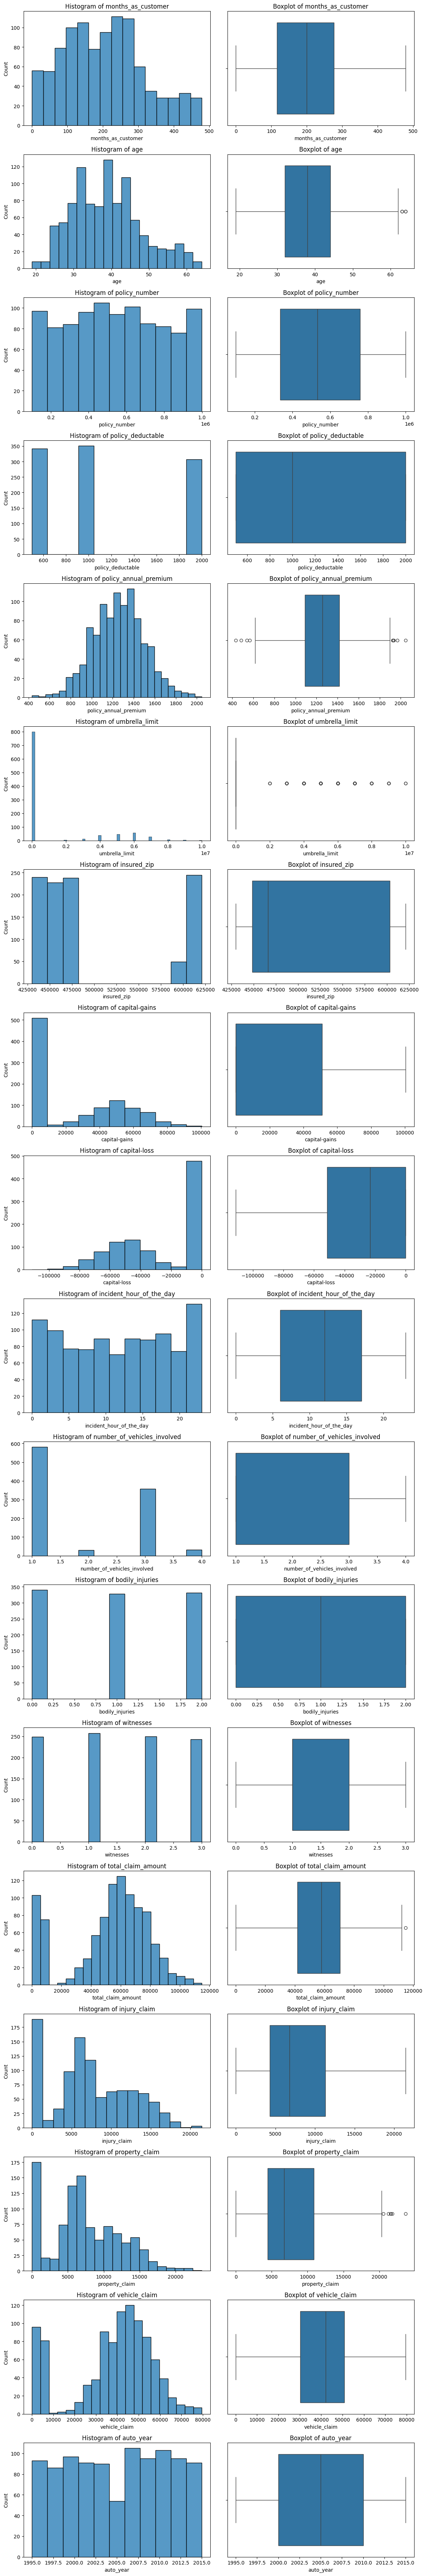

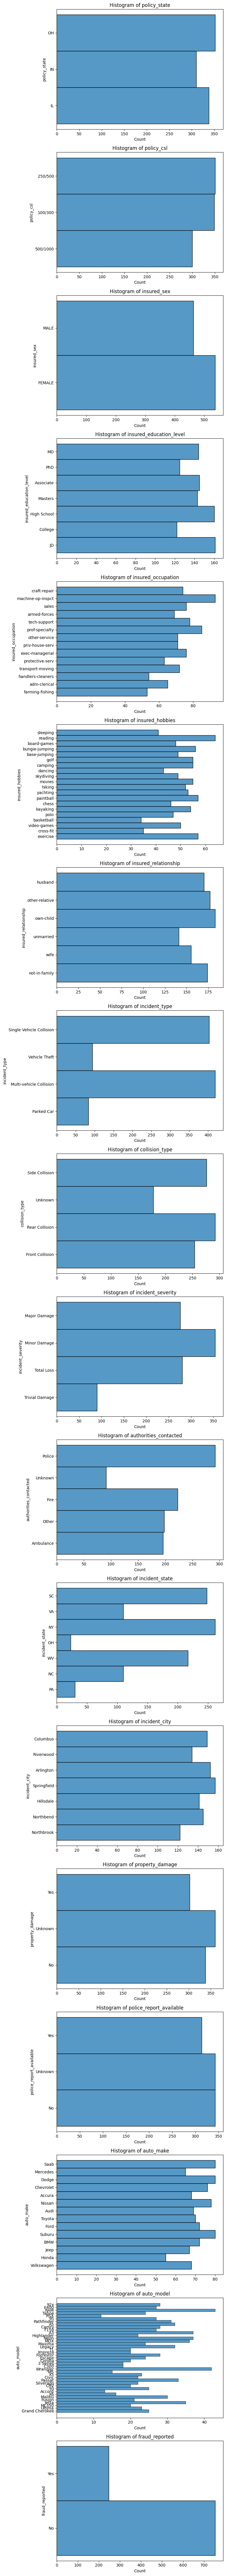

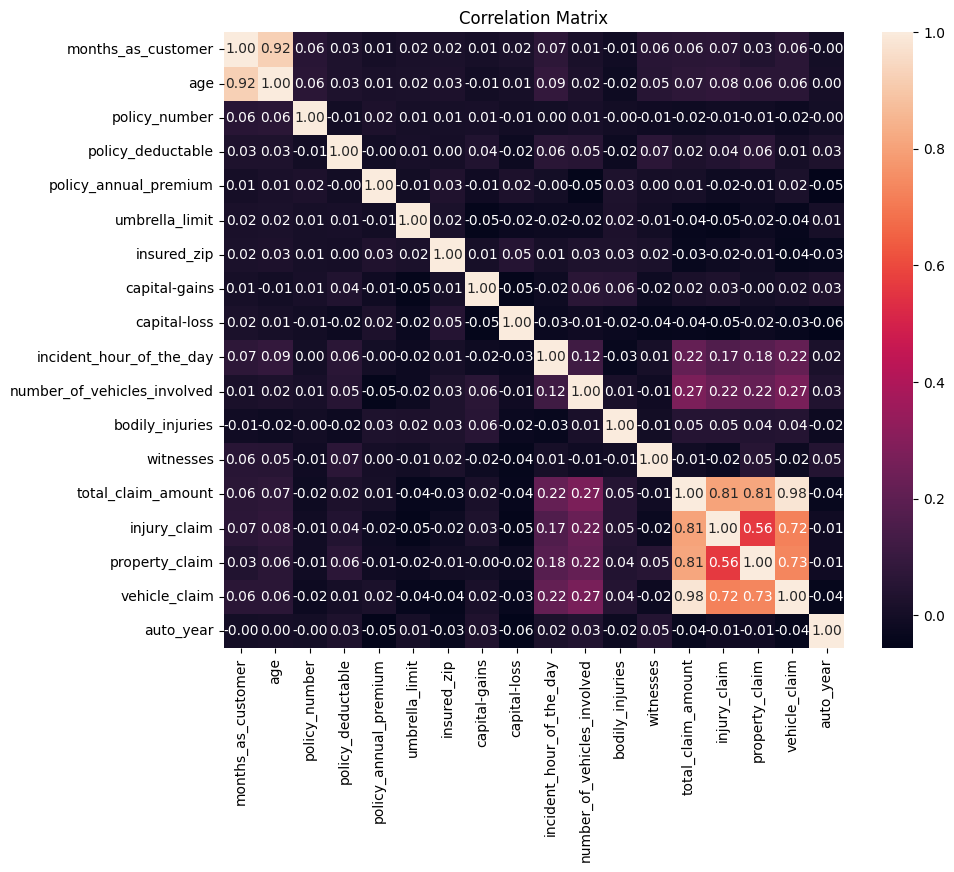

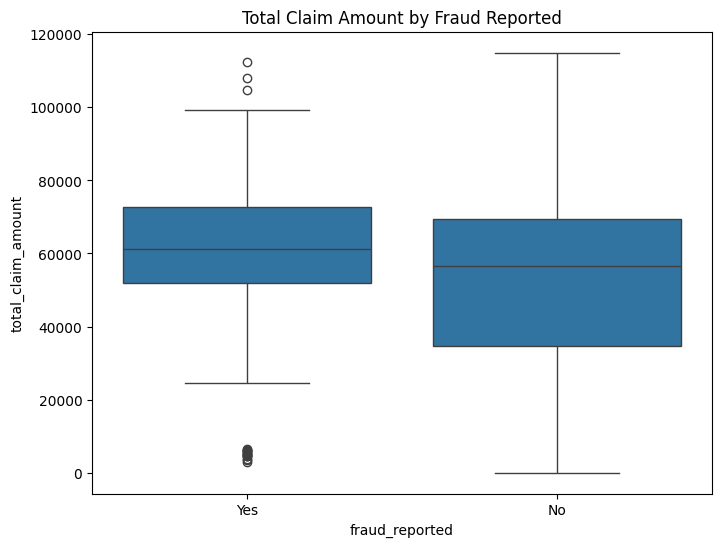

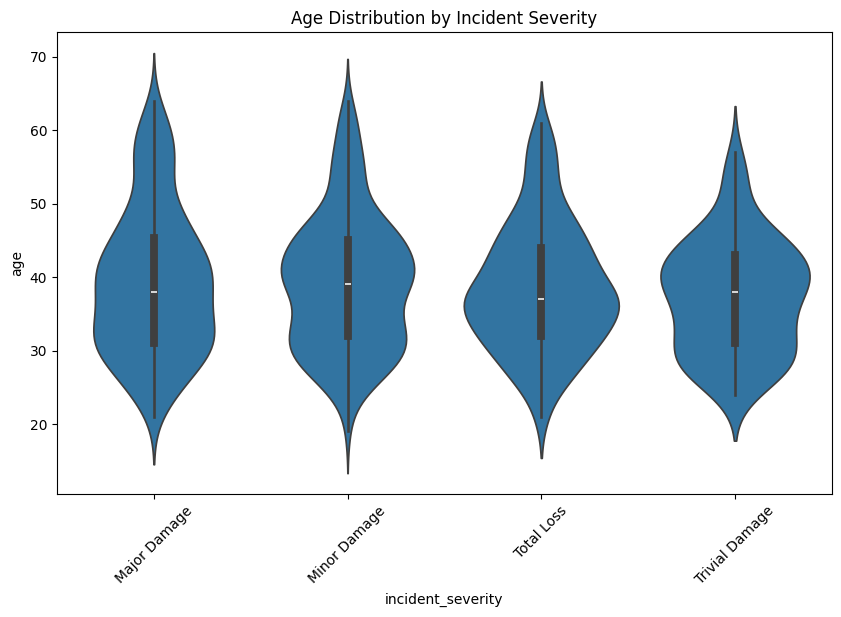

In [279]:
plot_hist_numeric(df)
plot_hist_text(df)
plot_correlation_matrix(df)
plot_bivariate(df)

Fraud reported values:  fraud_reported
No     0.753
Yes    0.247
Name: proportion, dtype: float64


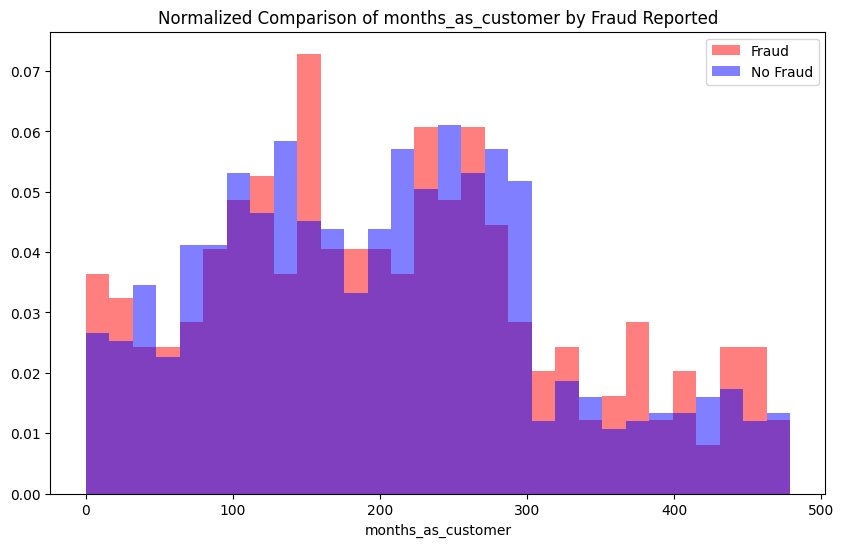

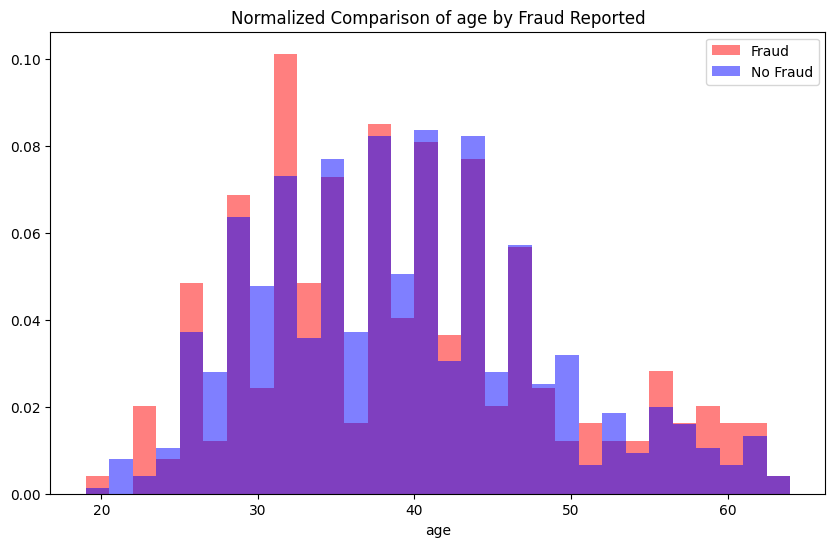

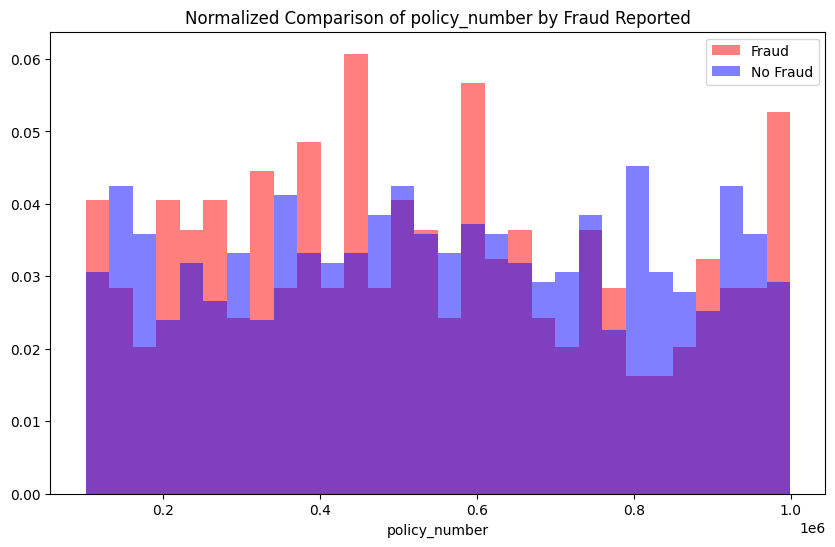

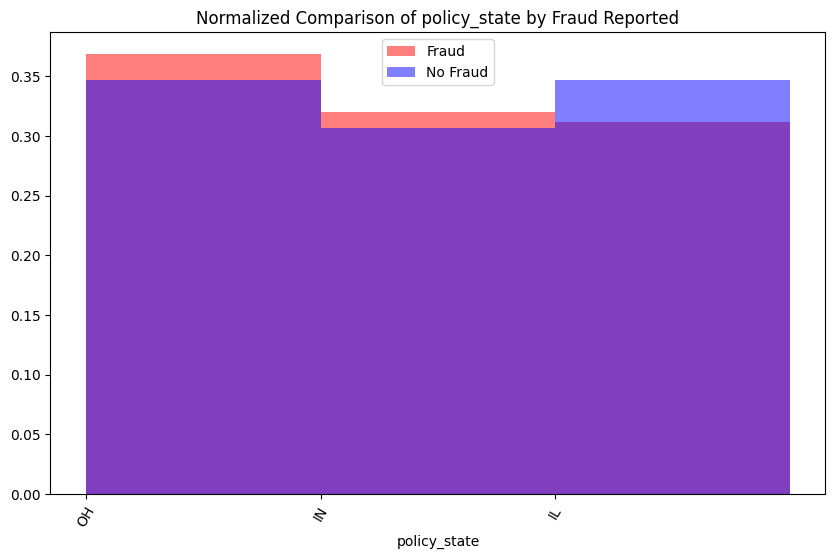

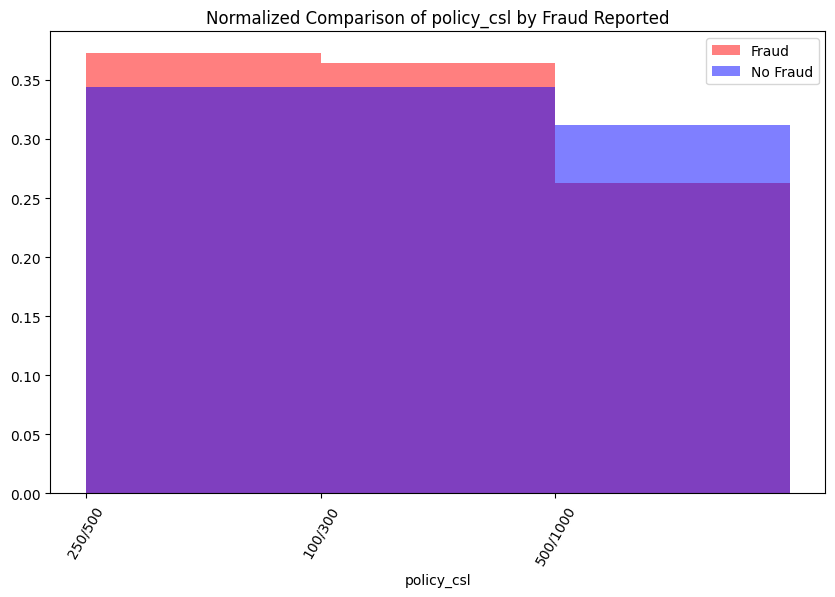

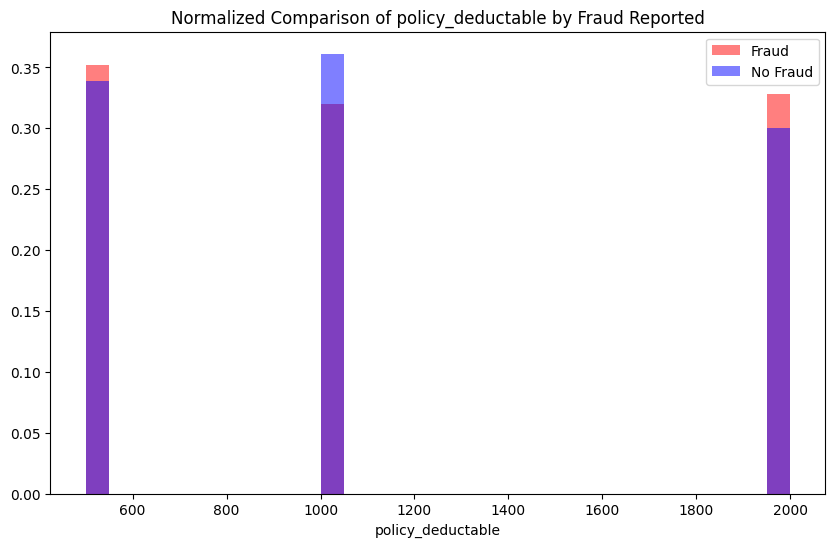

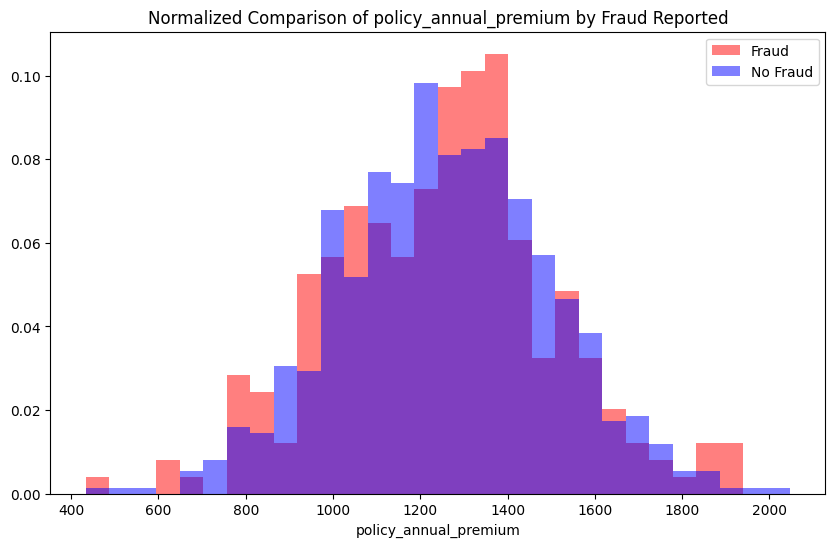

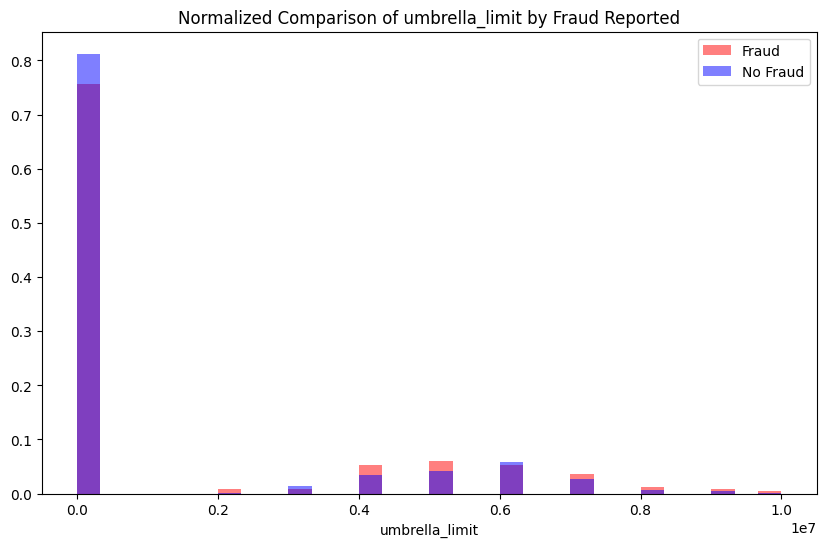

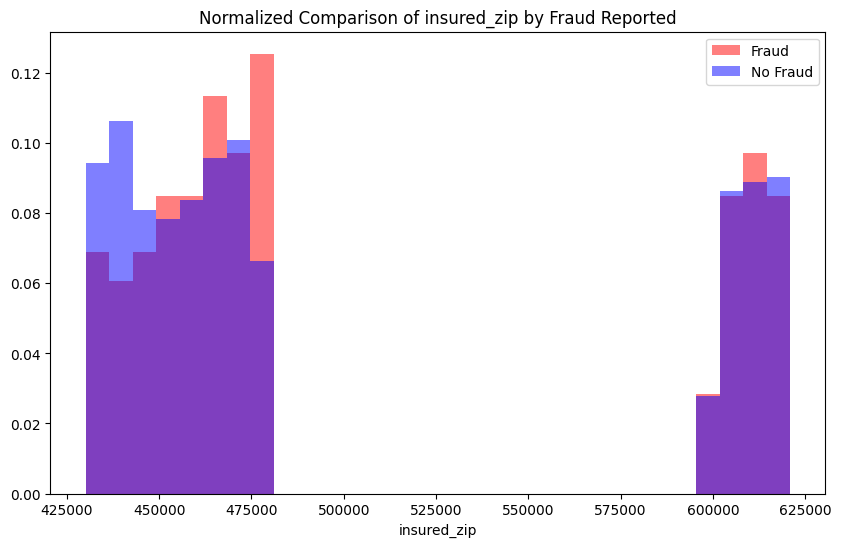

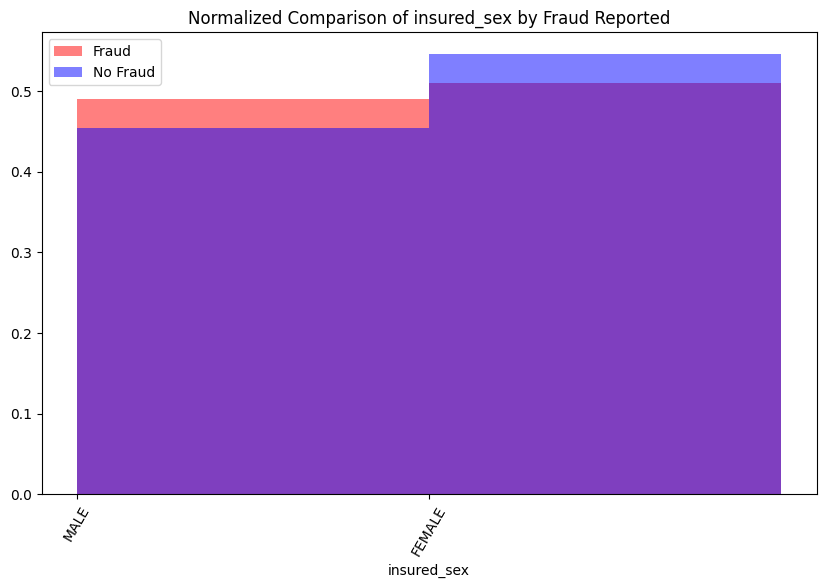

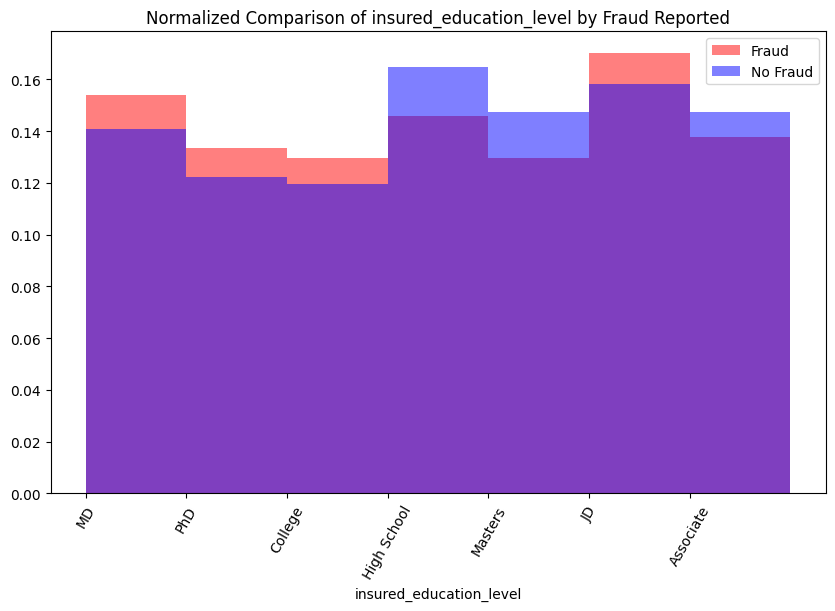

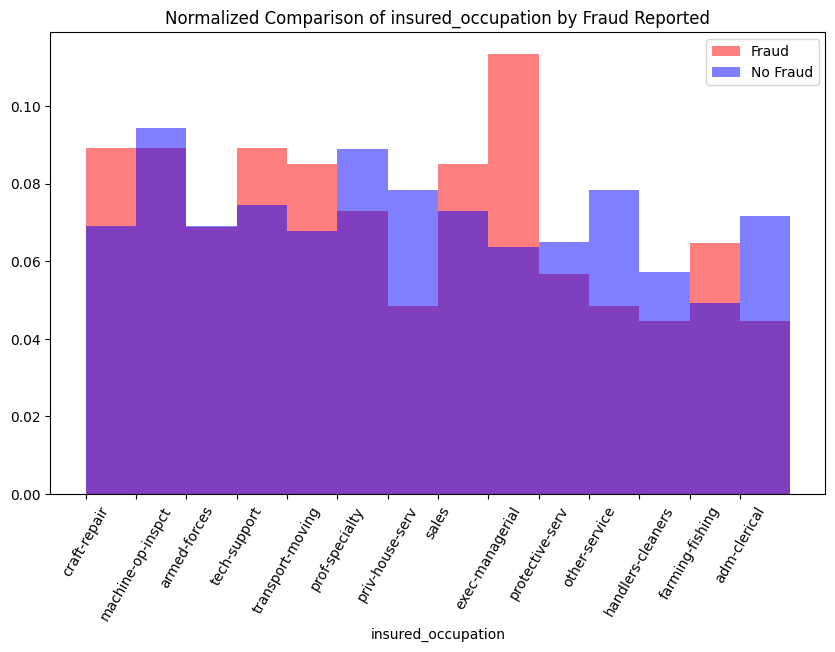

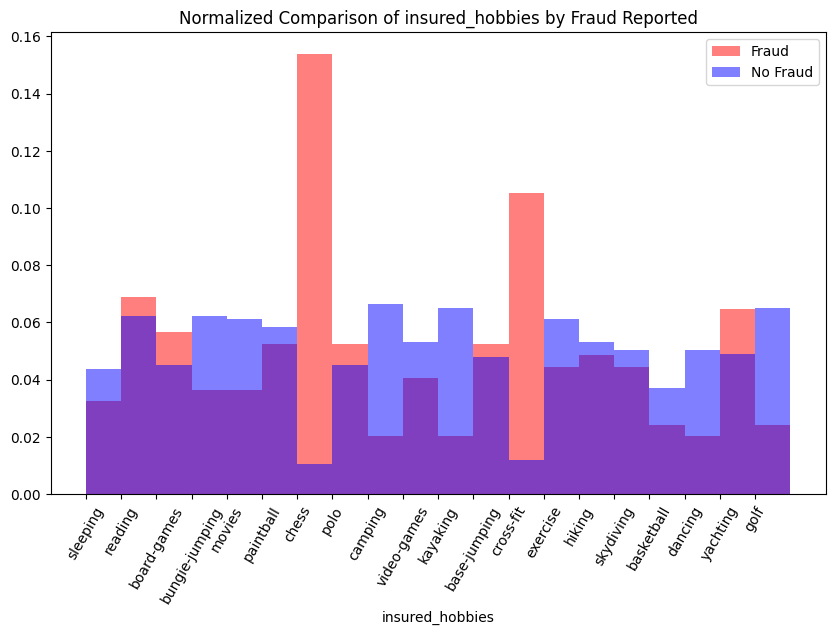

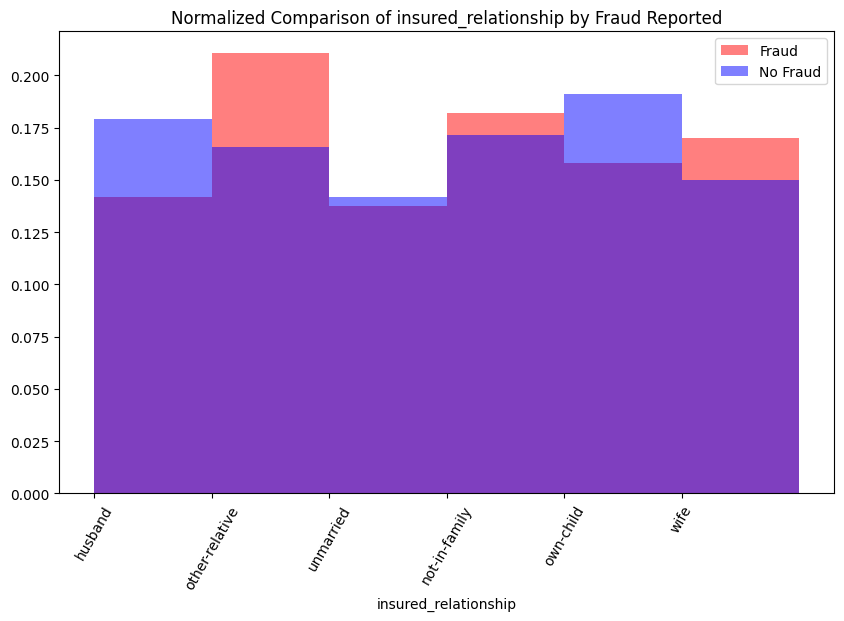

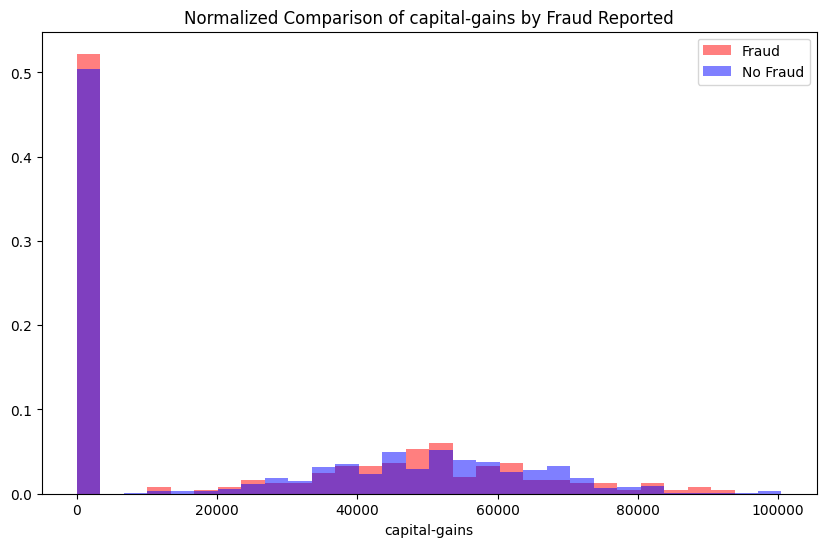

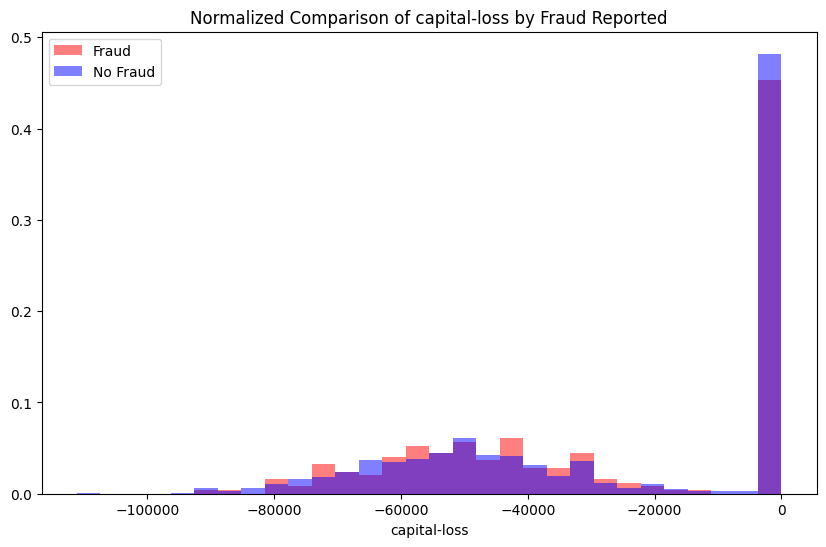

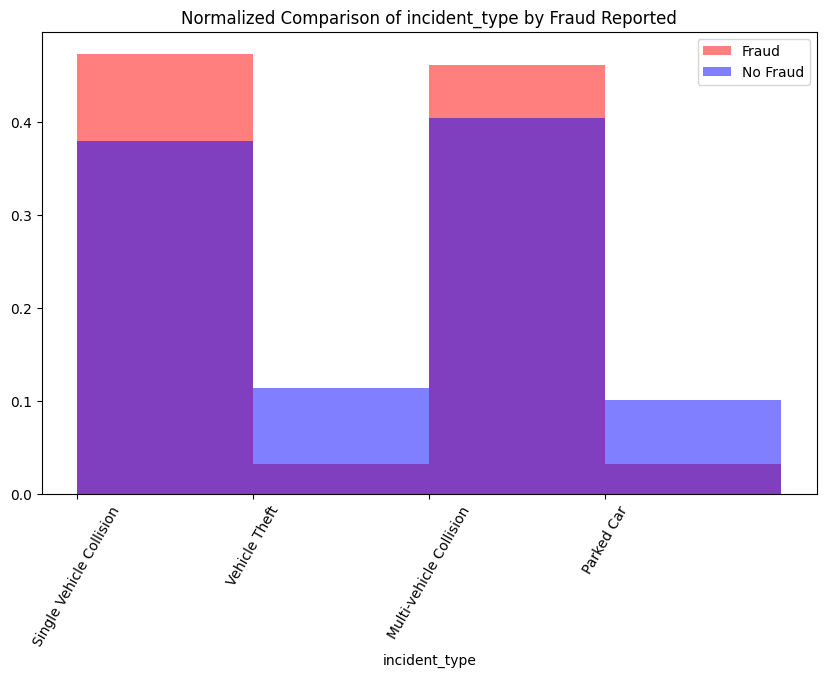

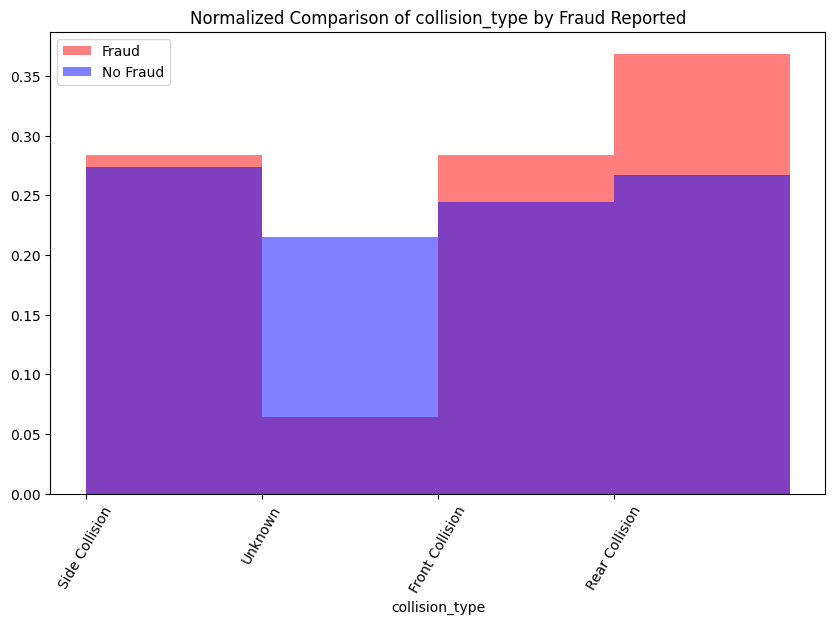

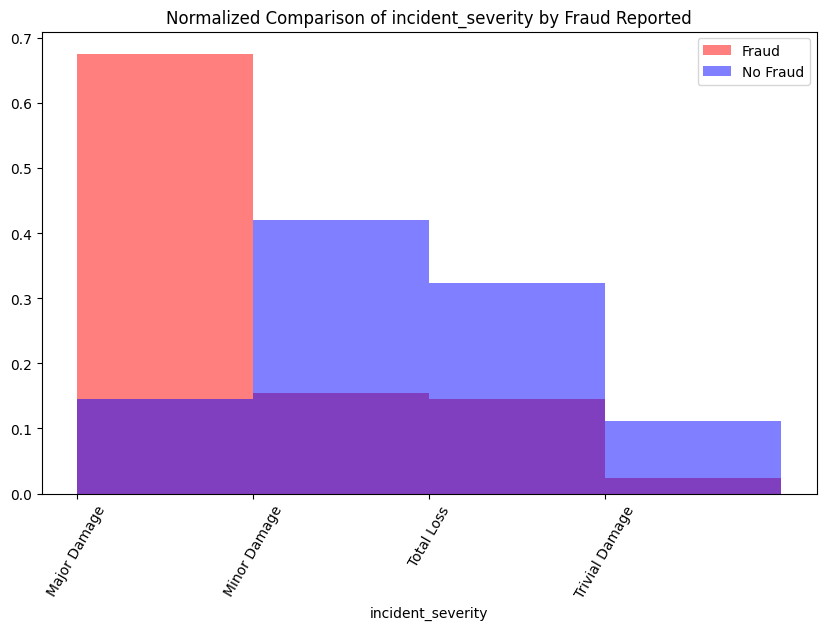

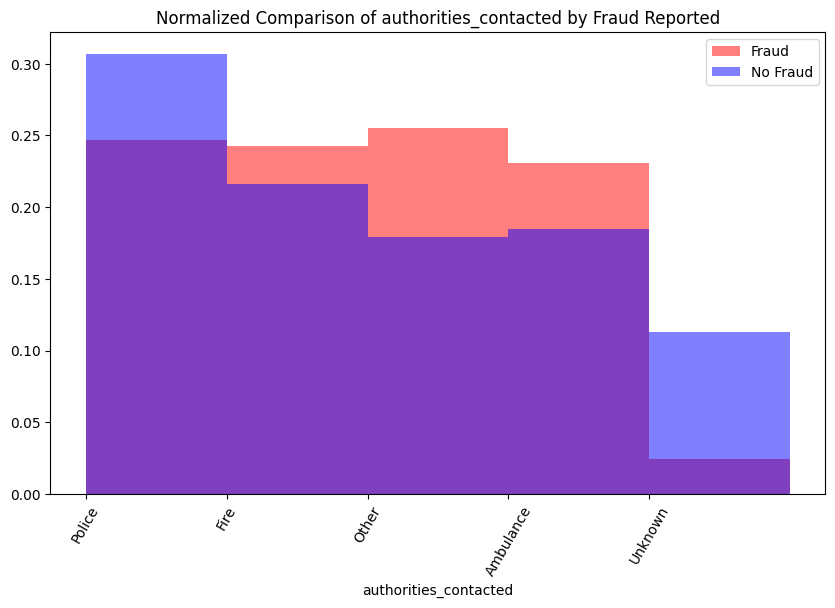

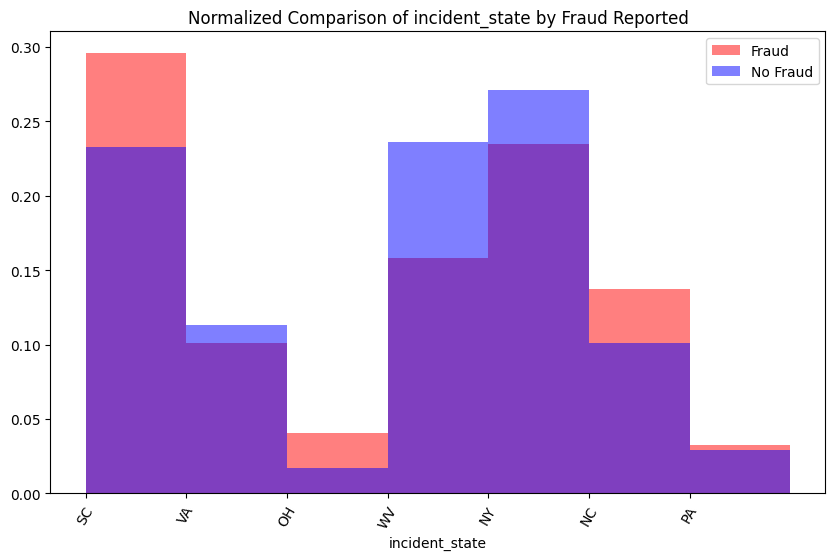

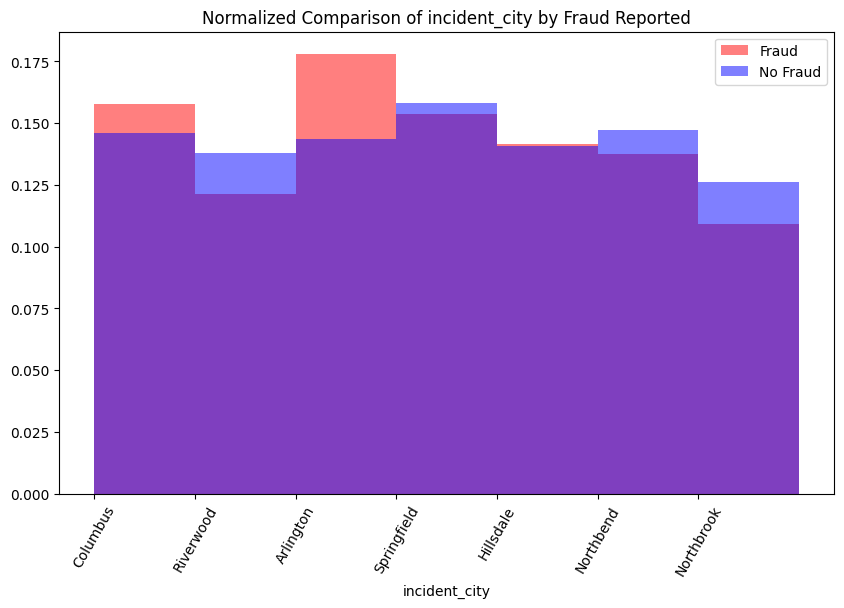

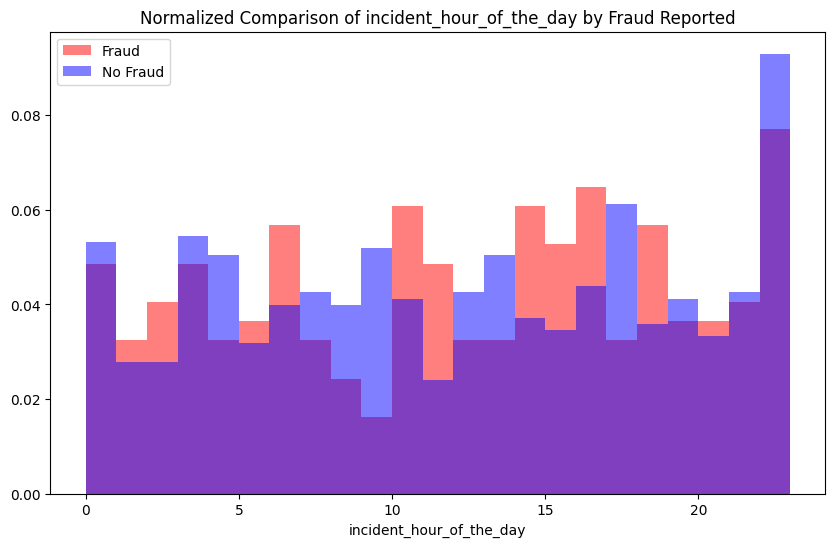

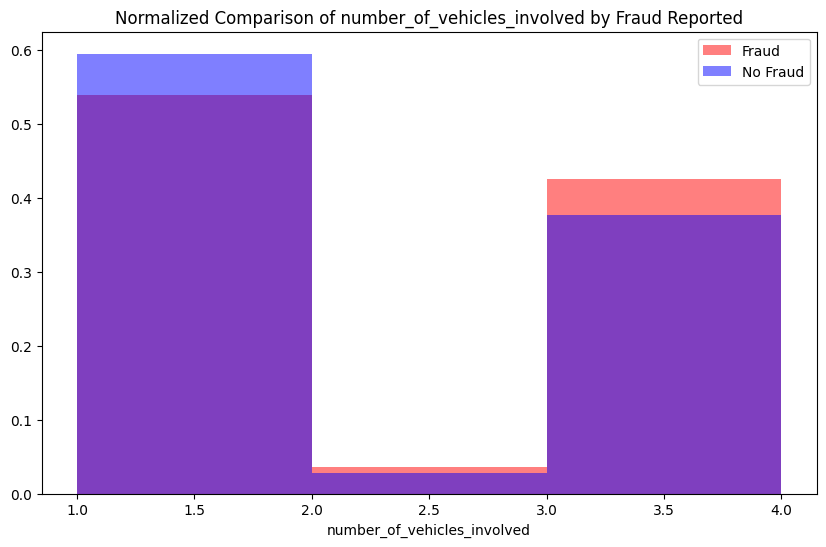

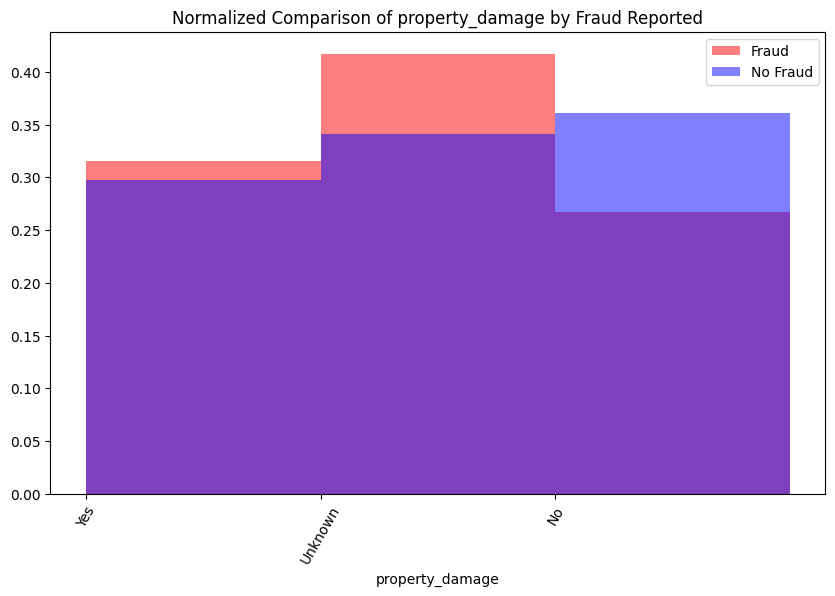

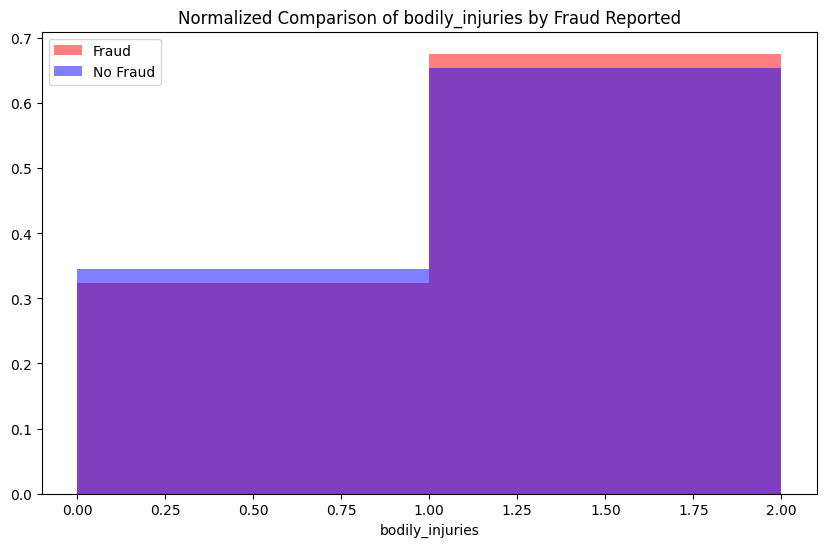

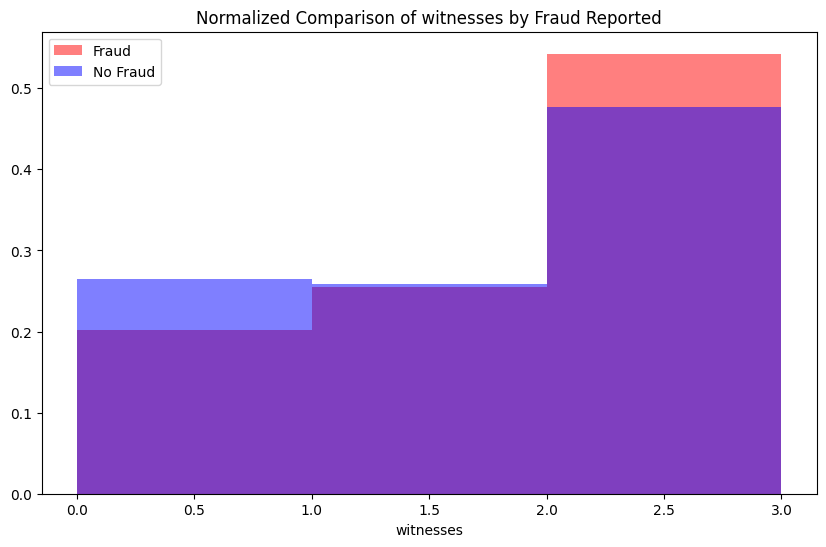

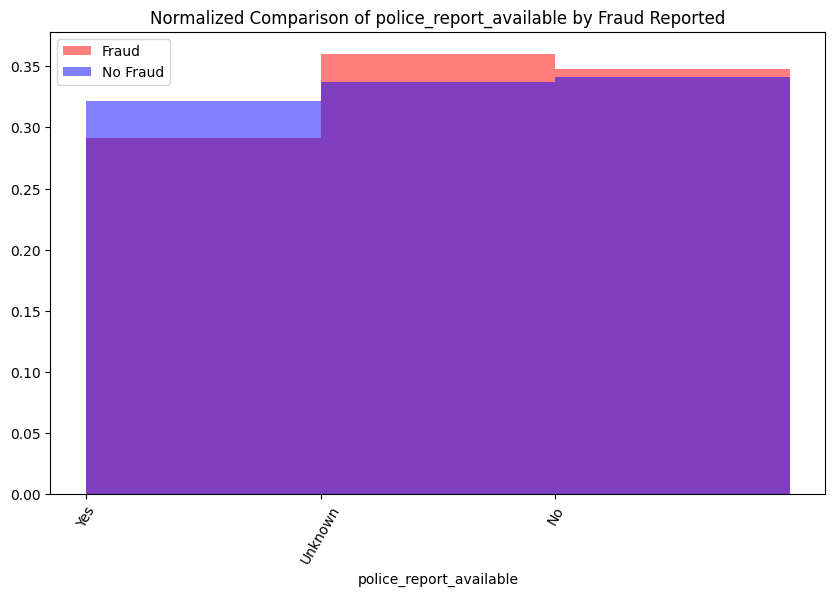

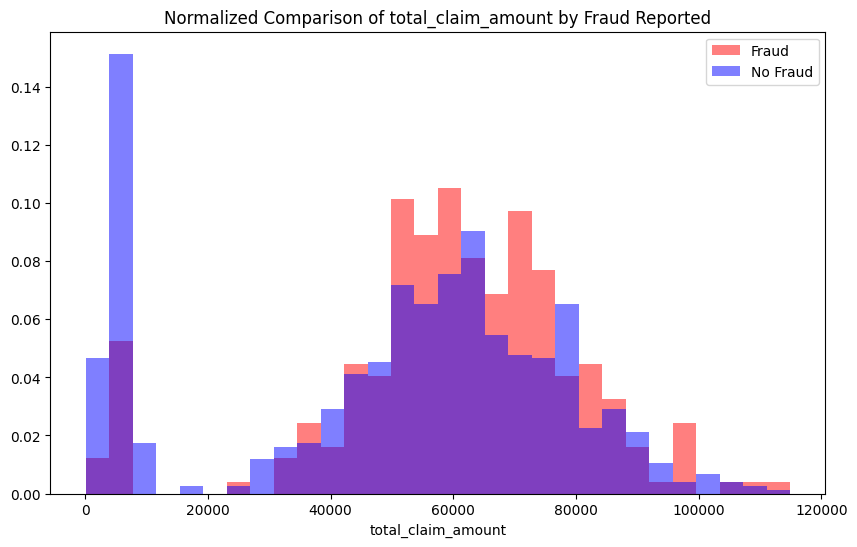

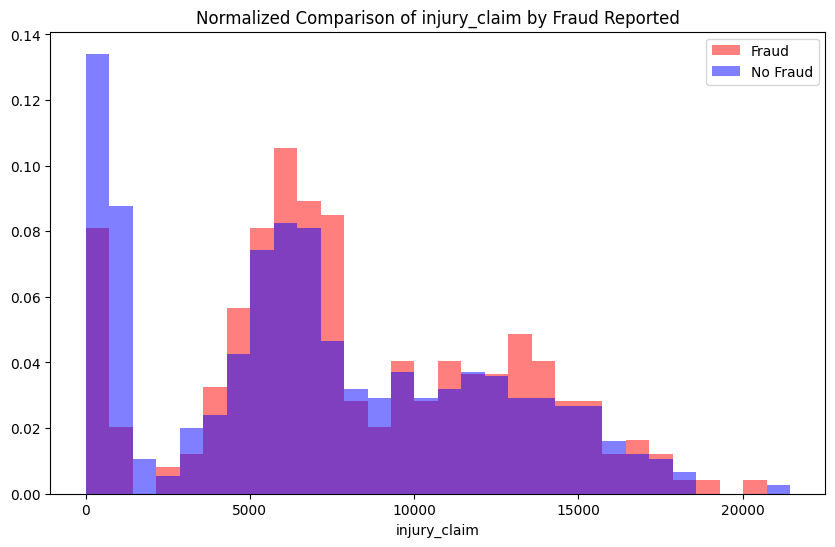

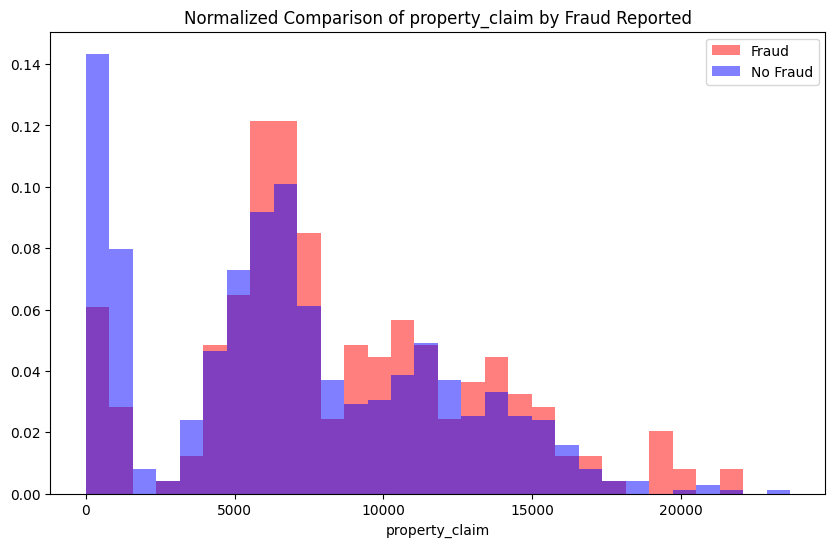

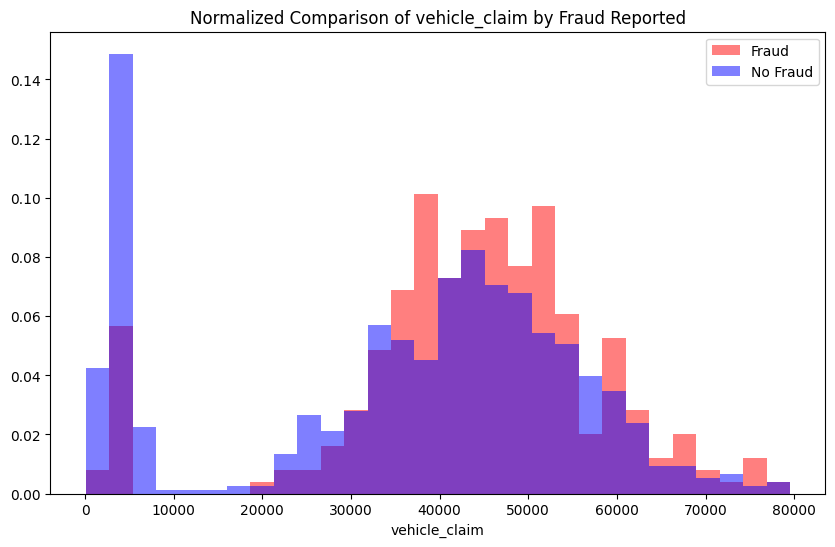

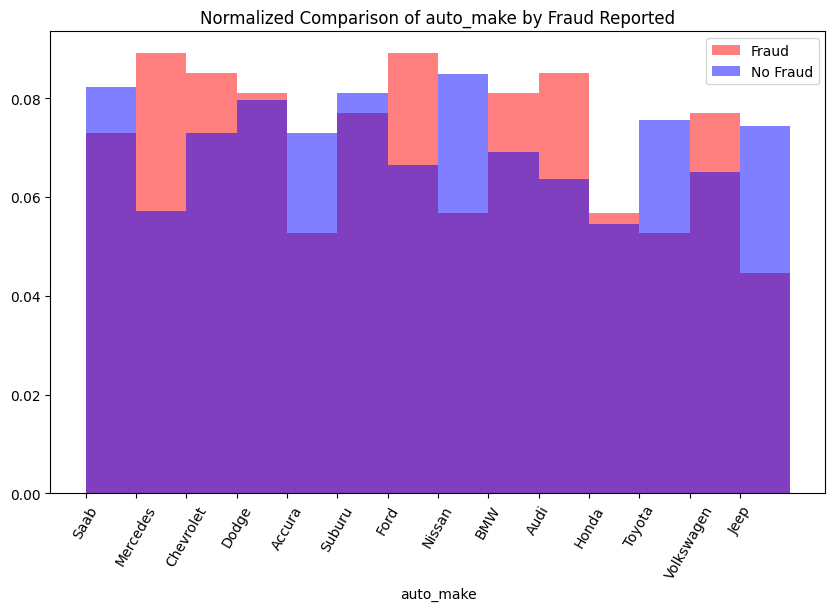

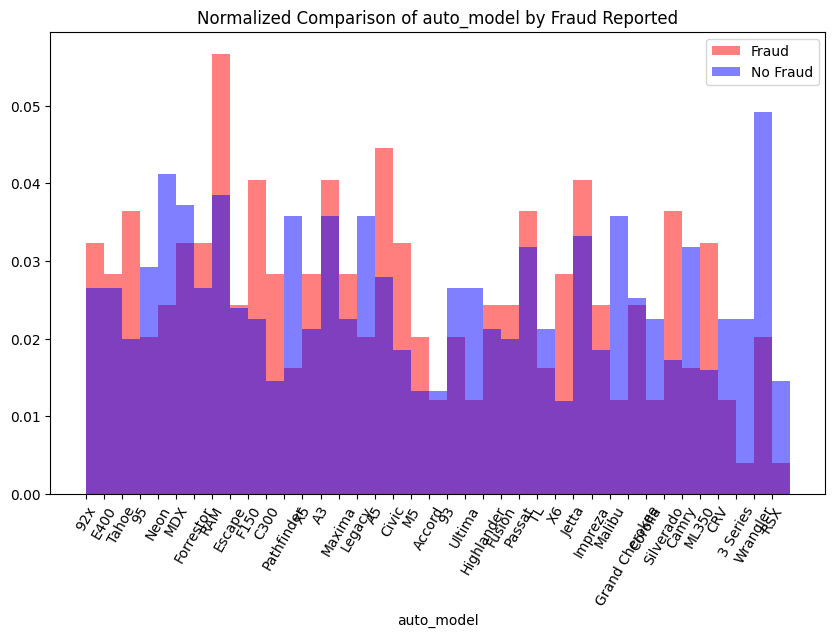

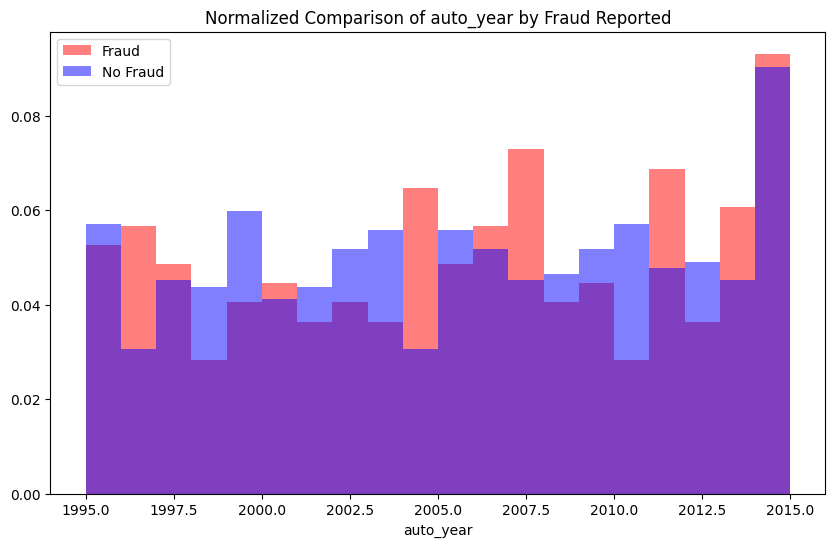

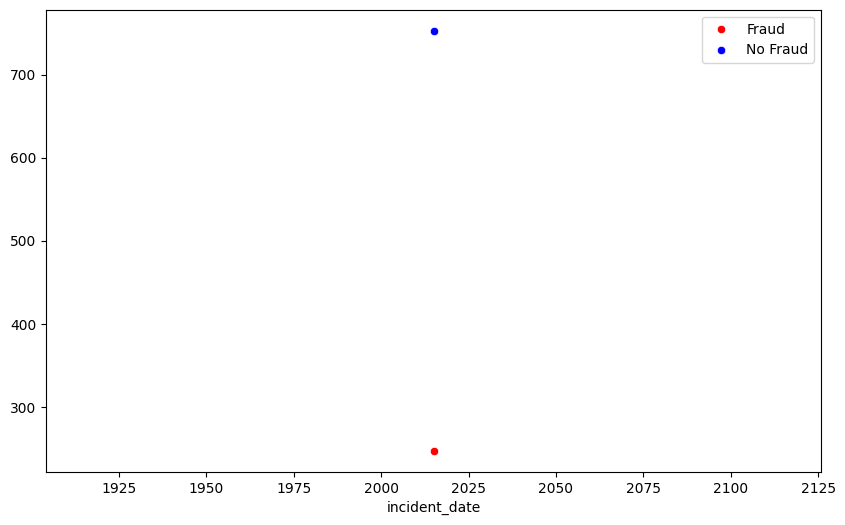

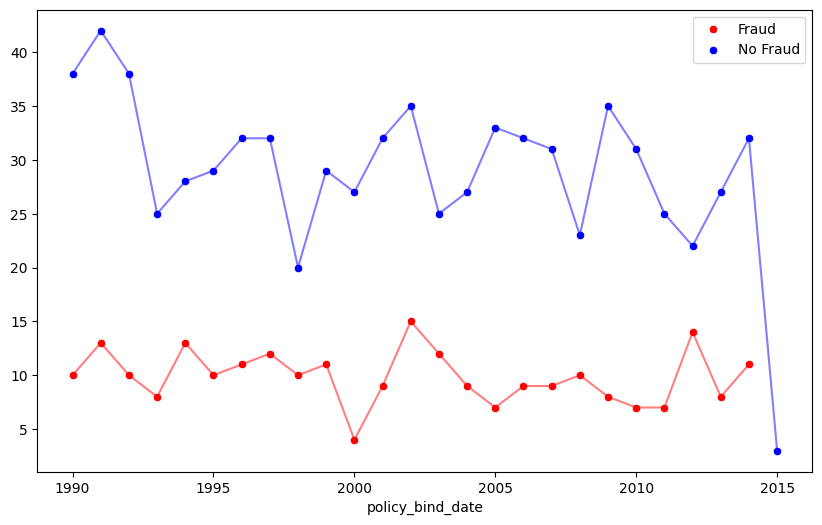

In [280]:
print("Fraud reported values: ", df['fraud_reported'].value_counts(normalize=True))
plot_fraud_comparison(df)

## 4. Feature engineering
- Creation of ratio features involving claim amounts and policy premium, which can potentially be good indicator of fraud

In [281]:
def add_features(df):
    print("Creating additional features for fraud patterns ...")
    df["claim_ratio"] = (
        df["total_claim_amount"] / (df["policy_annual_premium"] + 1)
    )

    df["injury_claim_ratio"] = (
        df["injury_claim"] / (df["total_claim_amount"] + 1)
    )

    df["vehicle_claim_ratio"] = (
        df["vehicle_claim"] / (df["total_claim_amount"] + 1)
    )

    df["property_claim_ratio"] = (
        df["property_claim"] / (df["total_claim_amount"]+ 1)
    )
    return df

In [282]:
df = add_features(df)

Creating additional features for fraud patterns ...


## 5. Splitting the dataset
- Datset partition into train (80%) and test (20%) data, using stratification to maintain the proportion of the target class. 
- No validation set due to the limited size of the dataset (1000 entries)   

In [283]:
from sklearn.model_selection import train_test_split

def split_data(df, target_col='fraud_reported', test_size=0.2, stratify=True, random_state=42):
    X = df.drop(columns=[target_col])
    y = df[target_col]

    stratify_vals = y if stratify else None

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        stratify=stratify_vals,
        random_state=random_state
    )
    return X_train, X_test, y_train, y_test

In [284]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw = split_data(df)

## 6. Categorical Data Encoding
- Binary and ordinal encoding of categorical features with boolean (Yes, No and Unknown) and ordered values
- One-Hot encoding of features with high potential impact on classification (based on EDA)
- Frequency encoding of high-cardinality features
- Data leakage prevention by fitting frequency and one-hot features only on train data and then mapping on test data

In [285]:
def encode_df(X_train, X_test, y_train, y_test):

    def encode_features(df, freq_maps=None, one_hot_categories=None, fit=False):
        df = df.copy()

        # Binary encoding
        df['insured_sex'] = df['insured_sex'].map({'FEMALE': 0, 'MALE': 1})
        df['property_damage'] = df['property_damage'].map({'No': 0, 'Yes': 1, 'Unknown': 2})
        df['police_report_available'] = df['police_report_available'].map({'No': 0, 'Yes': 1, 'Unknown': 2})

        # Ordinal encoding
        education_map = {
            'High School': 0, 
            'Associate': 1, 
            'College': 2,
            'Masters': 3, 
            'JD': 4, 
            'MD': 5, 
            'PhD': 6
        }
        df['insured_education_level'] = df['insured_education_level'].map(education_map)

        # policy_csl split
        df[['policy_csl_min', 'policy_csl_max']] = (
            df['policy_csl'].str.split('/', expand=True).astype(int)
        )
        df = df.drop(columns=['policy_csl'])

        # Date features
        df['incident_year']    = df['incident_date'].dt.year
        df['incident_month']   = df['incident_date'].dt.month
        df['incident_day']     = df['incident_date'].dt.day
        df['incident_weekday'] = df['incident_date'].dt.weekday
        df['policy_year']      = df['policy_bind_date'].dt.year
        df['policy_age_days']  = (df['incident_date'] - df['policy_bind_date']).dt.days
        df = df.drop(columns=['incident_date', 'policy_bind_date'])

        # Drop useless columns
        df = df.drop(columns=['policy_number', 'incident_location', 'insured_zip'], errors='ignore')

        # Frequency encoding — fit only on train
        high_card_cols = ['incident_city', 'insured_occupation', 'auto_make', 'auto_model']
        if fit:
            freq_maps = {col: df[col].value_counts().to_dict() for col in high_card_cols}
        for col in high_card_cols:
            df[col] = df[col].map(freq_maps[col]).fillna(0)

        # One-hot encoding — fit only on train
        one_hot_cols = [
            'incident_severity', 
            'incident_type', 
            'collision_type',
            'authorities_contacted', 
            'policy_state', 
            'incident_state',
            'insured_relationship', 
            'insured_hobbies'
        ]
        if fit:
            df = pd.get_dummies(df, columns=one_hot_cols, drop_first=False)
            one_hot_categories = df.columns.tolist()
        else:
            df = pd.get_dummies(df, columns=one_hot_cols, drop_first=False)
            # Align test to train columns — fills missing with 0, drops extras
            df = df.reindex(columns=one_hot_categories, fill_value=0)
        
        df.columns = df.columns.str.replace(' ', '_').str.lower()

        return df, freq_maps, one_hot_categories

    X_train_enc, freq_maps, one_hot_categories = encode_features(X_train, fit=True)
    X_test_enc, _, _  = encode_features(X_test, freq_maps, one_hot_categories, fit=False)

    # Encode targets here, alongside the features
    y_train_enc = y_train.map({'Yes': 1, 'No': 0})
    y_test_enc  = y_test.map({'Yes': 1, 'No': 0})

    return X_train_enc, X_test_enc, y_train_enc, y_test_enc

In [286]:
X_train, X_test, y_train, y_test = encode_df(X_train_raw, X_test_raw, y_train_raw, y_test_raw)
display(X_train.info())
display(X_train.head())

<class 'pandas.DataFrame'>
Index: 800 entries, 887 to 594
Data columns (total 89 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   months_as_customer                      800 non-null    int64  
 1   age                                     800 non-null    int64  
 2   policy_deductable                       800 non-null    int64  
 3   policy_annual_premium                   800 non-null    float64
 4   umbrella_limit                          800 non-null    int64  
 5   insured_sex                             800 non-null    int64  
 6   insured_education_level                 800 non-null    int64  
 7   insured_occupation                      800 non-null    int64  
 8   capital-gains                           800 non-null    int64  
 9   capital-loss                            800 non-null    int64  
 10  incident_city                           800 non-null    int64  
 11  inciden

None

,months_as_customer,age,policy_deductable,policy_annual_premium,umbrella_limit,insured_sex,insured_education_level,insured_occupation,capital-gains,capital-loss,...,insured_hobbies_hiking,insured_hobbies_kayaking,insured_hobbies_movies,insured_hobbies_paintball,insured_hobbies_polo,insured_hobbies_reading,insured_hobbies_skydiving,insured_hobbies_sleeping,insured_hobbies_video-games,insured_hobbies_yachting
887,441,55,500,1270.29,4000000,1,2,55,24000,-50500,...,False,False,False,False,False,False,False,False,False,False
317,275,45,2000,1447.77,0,0,1,58,39400,-63900,...,False,False,False,False,False,False,False,False,False,False
796,421,56,500,1935.85,4000000,1,3,72,49500,-81100,...,False,False,False,False,False,True,False,False,False,False
425,4,34,500,1282.93,0,0,2,62,0,0,...,False,False,False,False,False,False,False,False,False,False
991,257,44,1000,1280.88,0,1,5,47,59400,-32200,...,False,False,False,False,False,False,False,False,False,False


In [287]:
# Quality checks before RFECV and ML
print("Non-numeric columns:")
print(X_train.select_dtypes(include=['str']).columns)

print("Empty values in encoded dataset:")
print(X_train.isnull().sum().loc[X_train.isnull().sum() > 0])

Non-numeric columns:
Index([], dtype='str')
Empty values in encoded dataset:
Series([], dtype: int64)


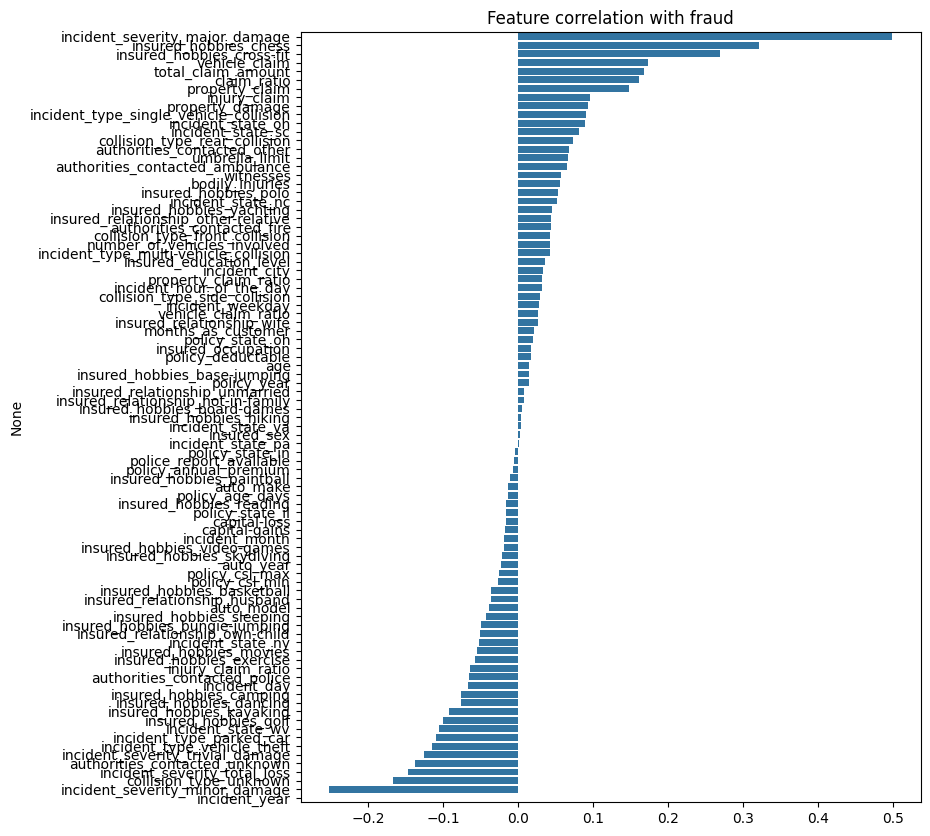

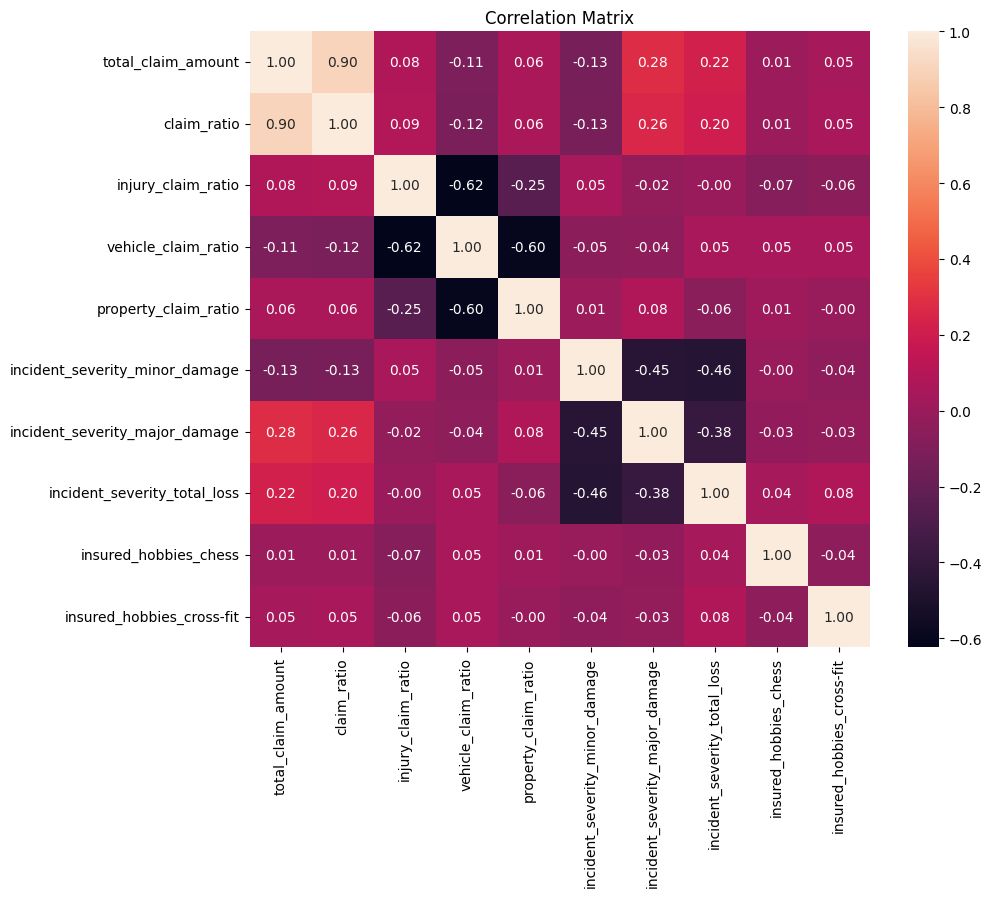

In [288]:
def plot_fraud_correlation(X_train, y_train):
    df_temp = X_train.copy()
    df_temp['fraud_reported'] = y_train.values

    corr_target = df_temp.corr(numeric_only=True)['fraud_reported'].sort_values(ascending=False)
    corr_target = corr_target.drop('fraud_reported')

    plt.figure(figsize=(8, 10))
    sns.barplot(x=corr_target.values, y=corr_target.index)
    plt.title("Feature correlation with fraud")
    plt.show()

plot_fraud_correlation(X_train, y_train)
plot_correlation_matrix(X_train[['total_claim_amount', 
                                 'claim_ratio', 
                                 'injury_claim_ratio', 
                                 'vehicle_claim_ratio', 
                                 'property_claim_ratio', 
                                 'incident_severity_minor_damage', 
                                 'incident_severity_major_damage', 
                                 'incident_severity_total_loss',
                                 'insured_hobbies_chess',
                                 'insured_hobbies_cross-fit']])

## 7. Recursive Feature Elimination
- Feature selection with Recursive Feature Elimination with Cross-Validation (RFECV) to eliminate redundant features and improve generalization
- Optimal number of features determined by maximizing the ROC-AUC score

In [289]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay, confusion_matrix, PrecisionRecallDisplay, average_precision_score

In [290]:
def train_rfecv(scaler, model, cv, X_train, y_train):
    pipeline_rfe = Pipeline([('scaler', scaler), ('model', model)])

    importance_getter = 'named_steps.model.coef_' if isinstance(model, LogisticRegression) else 'named_steps.model.feature_importances_'

    rfecv = RFECV(
        estimator=pipeline_rfe,
        step=1,
        cv=cv,
        scoring='roc_auc',
        min_features_to_select=2,
        n_jobs=-1,
        importance_getter=importance_getter
    )

    rfecv.fit(X_train, y_train)
    return rfecv

In [291]:
def get_rfecv_features(rfecv, X_train):
    selected_features = X_train.columns[rfecv.support_]
    
    print(f"Number of selected features: {rfecv.n_features_}")
    print(f"Selected features: {list(selected_features)}")
    
    return selected_features

def evaluate_rfecv_model(rfecv, X_test, y_test):
    y_pred = rfecv.predict(X_test)
    print("RFECV baseline performance:")
    print(classification_report(y_test, y_pred))

In [292]:
def plot_rfecv_results(rfecv, selected_features, model_name="Logistic Regression"):

    # Plot mean test score vs number of features
    n_features = len(rfecv.cv_results_["mean_test_score"])
    plt.figure(figsize=(8,6))
    plt.xlabel("Number of features selected")
    plt.ylabel("Mean test ROC-AUC score")
    plt.plot(range(1, n_features + 1), rfecv.cv_results_["mean_test_score"])
    plt.fill_between(
        range(1, n_features + 1),
        rfecv.cv_results_["mean_test_score"] - rfecv.cv_results_["std_test_score"],
        rfecv.cv_results_["mean_test_score"] + rfecv.cv_results_["std_test_score"],
        alpha=0.3, color="lightblue"
    )
    plt.title(f"RFECV Scores vs Number of Features ({model_name})")
    plt.show()

    try:
        # For linear models
        importances = abs(rfecv.estimator_.named_steps['model'].coef_[0])
    except AttributeError:
        # For tree-based models
        importances = rfecv.estimator_.named_steps['model'].feature_importances_

    importance_df = pd.DataFrame({
        'feature': selected_features,
        'importance': importances
    }).sort_values(by='importance', ascending=False)

    print(importance_df)

    # Plot feature importance
    importance_df.plot(kind='barh', x='feature', y='importance', figsize=(8,6), legend=False)
    plt.gca().invert_yaxis()
    plt.title(f'Feature Importance ({model_name})')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

In [293]:
def apply_rfecv_selection(rfecv, X_train, X_test):
    return rfecv.transform(X_train), rfecv.transform(X_test)

## 8. Model training, tuning and evaluation
- Model training using Randomized Search with Cross-Validation across the parameter grid
- Hyperparameter tuning focusing on ROC-AUC
- Model evaluation with classification scores and confusion matrix
- Learning curve monitoring
- Model calibration to obtain reliable output probabilities

In [294]:
def train_model(X_train, y_train, pipeline, param_grid, cv, scoring='roc_auc'):
    
    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_grid,
        n_iter=20,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        random_state=42
    )

    search.fit(X_train, y_train)

    print(f"\nBest parameters: {search.best_params_}")
    print(f"Best CV score: {search.best_score_:.4f}")

    return search

In [295]:
def evaluate_model(model, X_test, y_test):
    y_pred  = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1]

    print("\nTest Set Classification Report:")
    print(classification_report(y_test, y_pred))

    print(f"ROC-AUC: {roc_auc_score(y_test, y_score):.4f}")
    print(f"PR-AUC: {average_precision_score(y_test, y_score):.4f}")

    return y_pred, y_score

In [296]:
def plot_results(y_test, y_pred, y_score):
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    PrecisionRecallDisplay.from_predictions(y_test, y_score)
    plt.show()

In [297]:
def plot_learning_curve(estimator, X, y, cv=5, scoring='roc_auc', train_sizes=np.linspace(0.1, 1.0, 100), n_jobs=-1, title="Learning Curve"):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=estimator,
        X=X,
        y=y,
        cv=cv,
        scoring=scoring,
        n_jobs=n_jobs,
        train_sizes=train_sizes,
        shuffle=True,
        random_state=42
    )

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    plt.figure(figsize=(8,6))
    plt.plot(train_sizes, train_mean, label='Training score')
    plt.plot(train_sizes, val_mean, label='Validation score')

    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

    plt.xlabel("Number of training samples")
    plt.ylabel(scoring.upper())
    plt.title(title)
    plt.legend()
    plt.show()

In [298]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss

def calibrate_model(model, X_train, y_train, X_test, y_test, method='isotonic', cv=5, plot=True):    
    # Original model probabilities
    prob_orig = model.predict_proba(X_test)[:, 1]
    brier_orig = brier_score_loss(y_test, prob_orig)
    print(f"Original model Brier score: {brier_orig:.4f}")

    # Calibrated classifier
    calibrated_model = CalibratedClassifierCV(model, method=method, cv=cv)
    calibrated_model.fit(X_train, y_train)
    prob_cal = calibrated_model.predict_proba(X_test)[:, 1]
    brier_cal = brier_score_loss(y_test, prob_cal)
    print(f"Calibrated model Brier score ({method}): {brier_cal:.4f}")

    if plot:
        # Calibration curves
        frac_orig, mean_orig = calibration_curve(y_test, prob_orig, n_bins=10)
        frac_cal, mean_cal = calibration_curve(y_test, prob_cal, n_bins=10)

        plt.figure(figsize=(8, 6))
        plt.plot(mean_orig, frac_orig, "s-", label="Original")
        plt.plot(mean_cal, frac_cal, "s-", label=f"Calibrated ({method})")
        plt.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
        plt.xlabel("Mean predicted probability")
        plt.ylabel("Fraction of positives")
        plt.title("Calibration Curve")
        plt.legend()
        plt.show()

    return calibrated_model

In [299]:
import shap

def plot_shap_interpretation(pipeline, X_data, feature_names, row_index=0, title="SHAP Interpretation"):
    model = pipeline.named_steps['model']
    
    # Data preparation for SHAP
    if 'scaler' in pipeline.named_steps:
        X_proc = pipeline.named_steps['scaler'].transform(X_data)
    else:
        X_proc = X_data.values if hasattr(X_data, 'values') else X_data

    # Explainer choice based on model type
    if isinstance(model, XGBClassifier):
        explainer = shap.TreeExplainer(model)
    else:
        explainer = shap.LinearExplainer(model, X_proc)

    # SHAP values calculation for the dataset
    shap_values = explainer(X_proc)
    shap_values.feature_names = list(feature_names)

    # Global summary plot
    plt.figure(figsize=(10, 6))
    plt.title(f"Global: {title}")
    shap.summary_plot(shap_values, X_proc, feature_names=list(feature_names), show=False)
    plt.show()

    # Waterfall plot
    plt.figure(figsize=(10, 6))
    plt.title(f"Local: Investigation of Row {row_index}")
    shap.plots.waterfall(shap_values[row_index])
    plt.show()

## 9. Logistic Regression

 ### 9.1 RFFECV with Logistic Regression

In [300]:
scaler = StandardScaler()
model = LogisticRegression(class_weight='balanced', max_iter=4000, random_state=42)
cv = StratifiedKFold(5, shuffle=True, random_state=42)
rfecv = train_rfecv(scaler, model, cv, X_train, y_train)

In [301]:
selected_features = get_rfecv_features(rfecv, X_train)
evaluate_rfecv_model(rfecv, X_test, y_test)

Number of selected features: 5
Selected features: ['policy_csl_min', 'policy_csl_max', 'incident_severity_major_damage', 'insured_hobbies_chess', 'insured_hobbies_cross-fit']
RFECV baseline performance:
              precision    recall  f1-score   support

           0       0.95      0.84      0.89       151
           1       0.64      0.86      0.73        49

    accuracy                           0.84       200
   macro avg       0.79      0.85      0.81       200
weighted avg       0.87      0.84      0.85       200



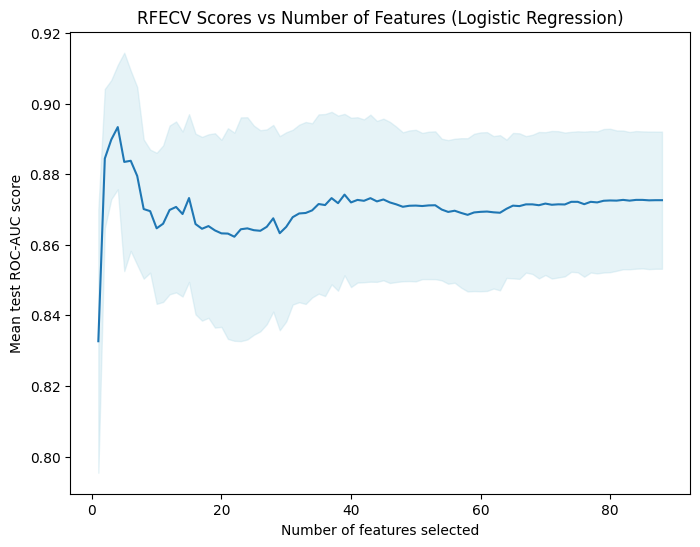

                          feature  importance
2  incident_severity_major_damage    1.519727
3           insured_hobbies_chess    1.006431
4       insured_hobbies_cross-fit    0.848171
1                  policy_csl_max    0.595696
0                  policy_csl_min    0.509795


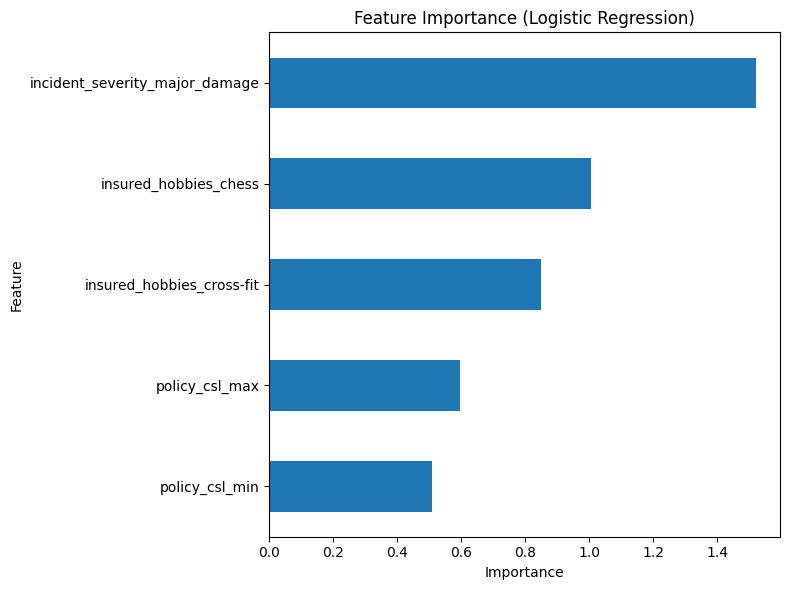

In [302]:
plot_rfecv_results(rfecv, selected_features, model_name="Logistic Regression")

In [303]:
X_train_lr, X_test_lr =  apply_rfecv_selection(rfecv, X_train, X_test)

### 9.2 Model tuning with Logistic Regression

In [304]:
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=4000,
        random_state=42
    ))
])

param_grid_lr = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__solver': ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
}

search_lr = train_model(X_train_lr, y_train, pipeline_lr, param_grid_lr, cv)
best_lr = search_lr.best_estimator_


Best parameters: {'model__solver': 'newton-cg', 'model__C': 10}
Best CV score: 0.8990


In [305]:
y_pred_lr, y_score_lr = evaluate_model(best_lr, X_test_lr, y_test)


Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.84      0.89       151
           1       0.64      0.86      0.73        49

    accuracy                           0.84       200
   macro avg       0.79      0.85      0.81       200
weighted avg       0.87      0.84      0.85       200

ROC-AUC: 0.8694
PR-AUC: 0.5747


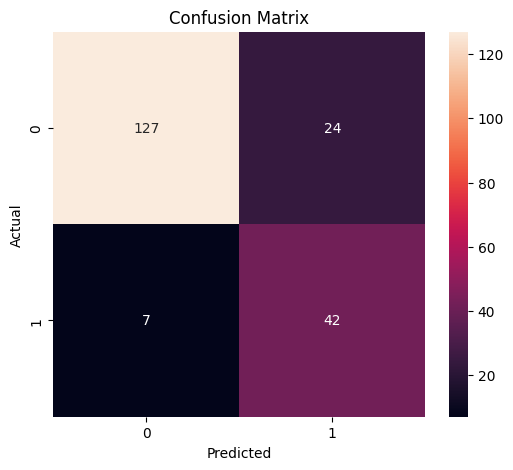

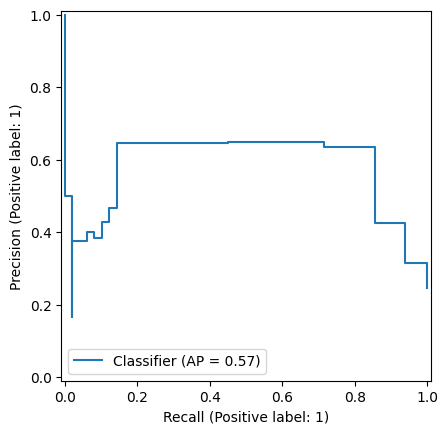

In [306]:
plot_results(y_test, y_pred_lr, y_score_lr)

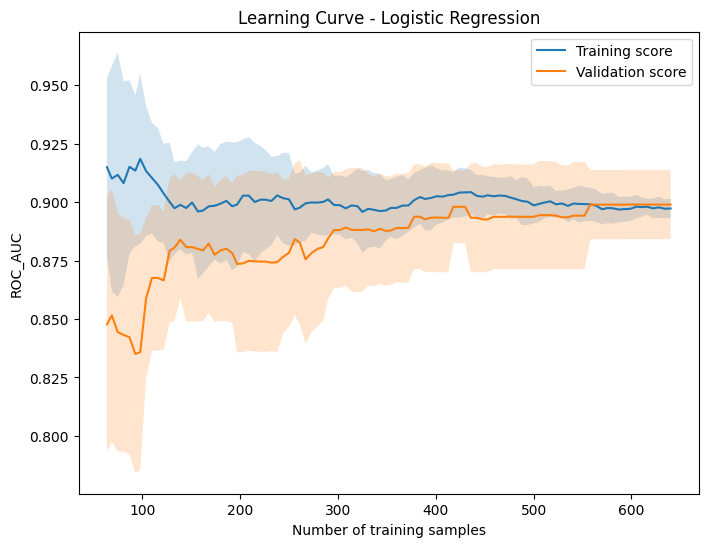

In [307]:
plot_learning_curve(best_lr, X_train_lr, y_train, cv=cv, scoring='roc_auc', title="Learning Curve - Logistic Regression")

Original model Brier score: 0.1310
Calibrated model Brier score (isotonic): 0.1211


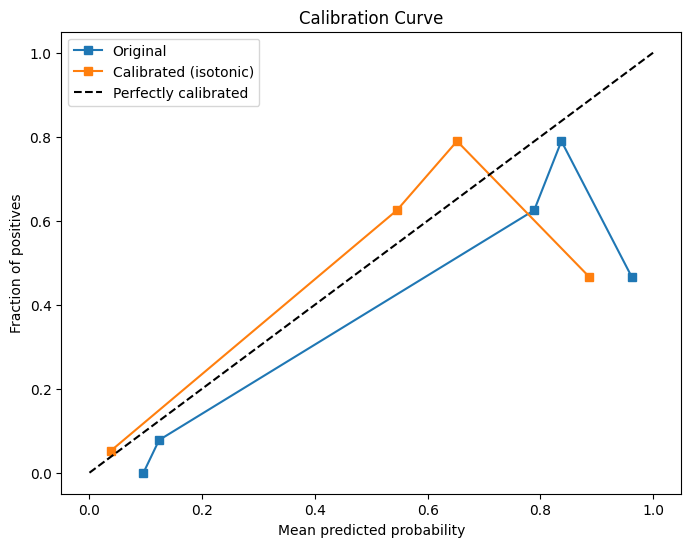


Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.84      0.89       151
           1       0.64      0.86      0.73        49

    accuracy                           0.84       200
   macro avg       0.79      0.85      0.81       200
weighted avg       0.87      0.84      0.85       200

ROC-AUC: 0.8697
PR-AUC: 0.5723


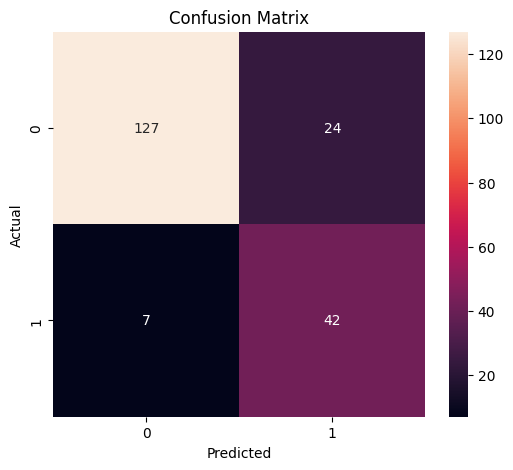

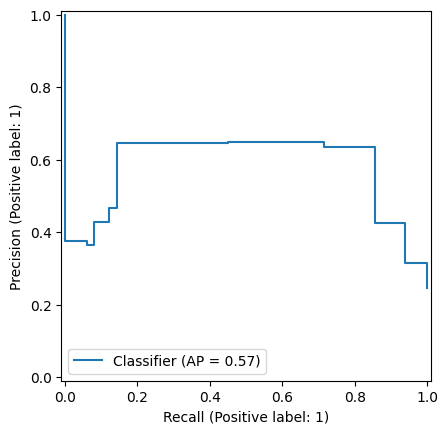

In [308]:
calibrated_lr = calibrate_model(best_lr, X_train_lr, y_train, X_test_lr, y_test, method='isotonic')

y_pred_cal = calibrated_lr.predict(X_test_lr)
y_score_cal = calibrated_lr.predict_proba(X_test_lr)[:, 1]

evaluate_model(calibrated_lr, X_test_lr, y_test)
plot_results(y_test, y_pred_cal, y_score_cal)

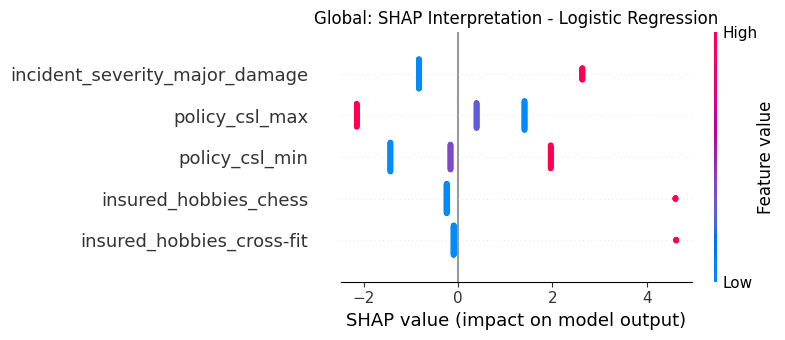

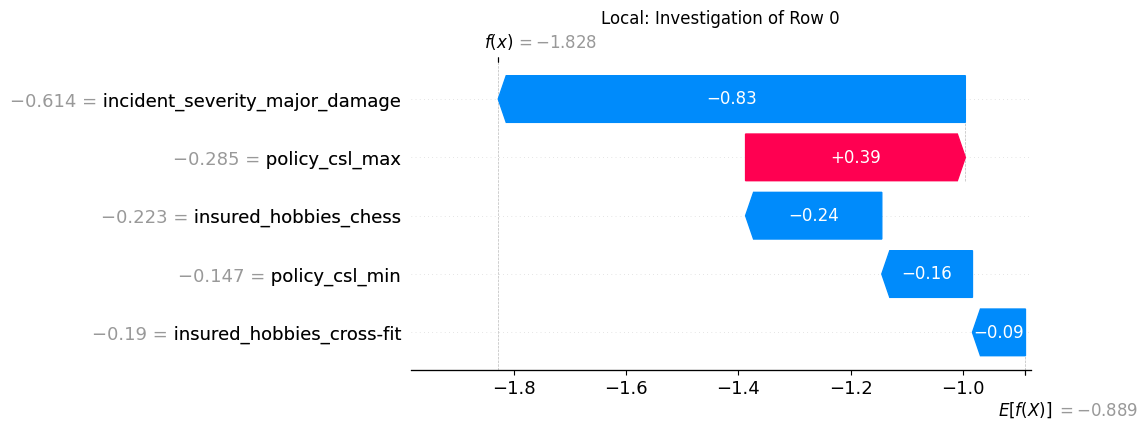

In [309]:
plot_shap_interpretation(best_lr, X_test_lr, feature_names=selected_features, title="SHAP Interpretation - Logistic Regression")

## 10. XGBoost Classifier

 ### 10.1. RFFECV with XGBoost

In [310]:
scaler = StandardScaler()
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
model = XGBClassifier(scale_pos_weight=neg/pos, random_state=42, max_depth=5,
                                   learning_rate=0.01, subsample=0.8)
cv = StratifiedKFold(5, shuffle=True, random_state=42)
rfecv = train_rfecv(scaler, model, cv, X_train, y_train)

In [311]:
selected_features = get_rfecv_features(rfecv, X_train)
evaluate_rfecv_model(rfecv, X_test, y_test)

Number of selected features: 3
Selected features: ['incident_severity_major_damage', 'insured_hobbies_chess', 'insured_hobbies_cross-fit']
RFECV baseline performance:
              precision    recall  f1-score   support

           0       0.95      0.84      0.89       151
           1       0.64      0.86      0.73        49

    accuracy                           0.84       200
   macro avg       0.79      0.85      0.81       200
weighted avg       0.87      0.84      0.85       200



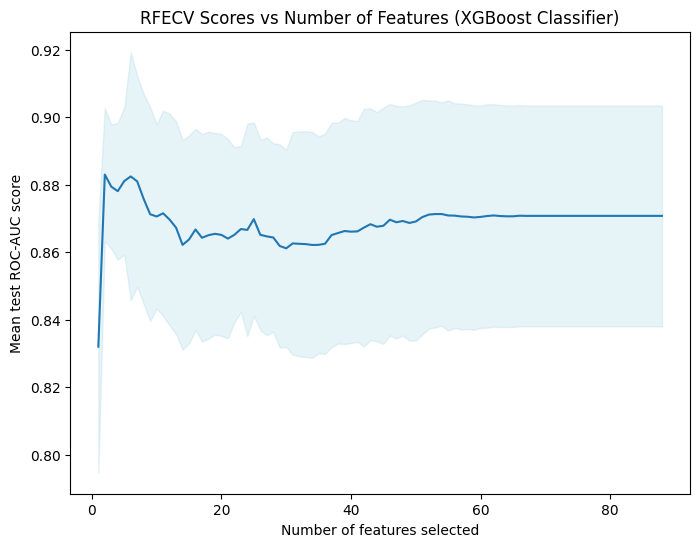

                          feature  importance
0  incident_severity_major_damage    0.520658
1           insured_hobbies_chess    0.260204
2       insured_hobbies_cross-fit    0.219138


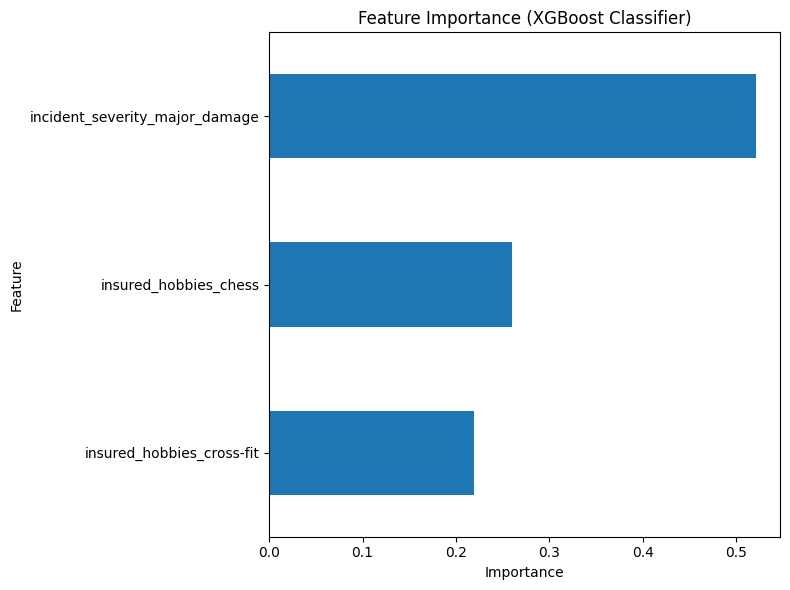

In [312]:
plot_rfecv_results(rfecv, selected_features, model_name="XGBoost Classifier")

In [313]:
X_train_xgb, X_test_xgb =  apply_rfecv_selection(rfecv, X_train, X_test)

### 10.2. Model tuning with XGBoost

In [314]:
pipeline_xgb = Pipeline([
    ('model', XGBClassifier(
        scale_pos_weight = (len(y_train) / sum(y_train)),
        random_state=42
    ))
])

param_grid_xgb = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2]
}

search_xgb = train_model(X_train_xgb, y_train, pipeline_xgb, param_grid_xgb, cv)
best_xgb = search_xgb.best_estimator_


Best parameters: {'model__n_estimators': 200, 'model__max_depth': 5, 'model__learning_rate': 0.01}
Best CV score: 0.8848


In [315]:
y_pred_xgb, y_score_xgb = evaluate_model(best_xgb, X_test_xgb, y_test)


Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.84      0.89       151
           1       0.64      0.86      0.73        49

    accuracy                           0.84       200
   macro avg       0.79      0.85      0.81       200
weighted avg       0.87      0.84      0.85       200

ROC-AUC: 0.8398
PR-AUC: 0.5916


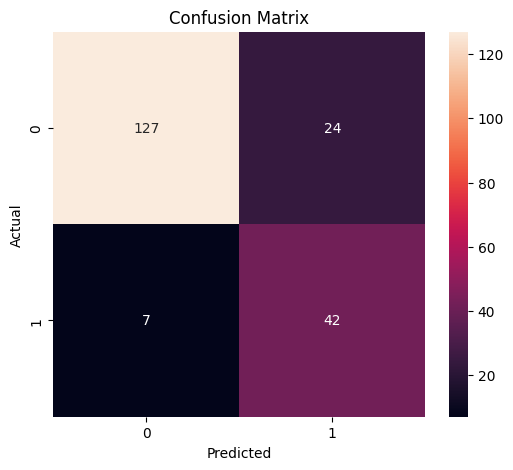

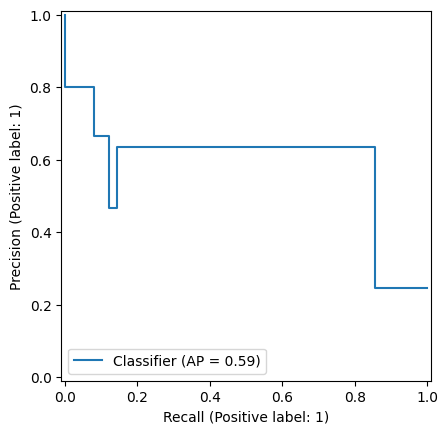

In [316]:
plot_results(y_test, y_pred_xgb, y_score_xgb)

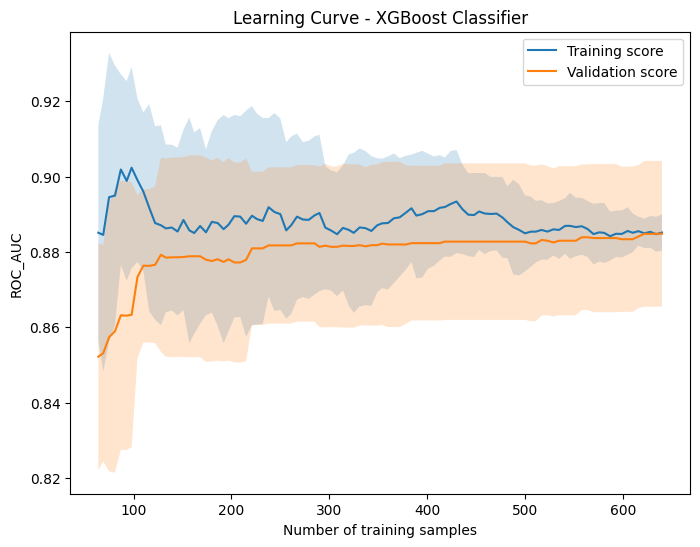

In [317]:
plot_learning_curve(best_xgb, X_train_xgb, y_train, cv=cv, scoring='roc_auc', title="Learning Curve - XGBoost Classifier")

Original model Brier score: 0.1381
Calibrated model Brier score (sigmoid): 0.1111


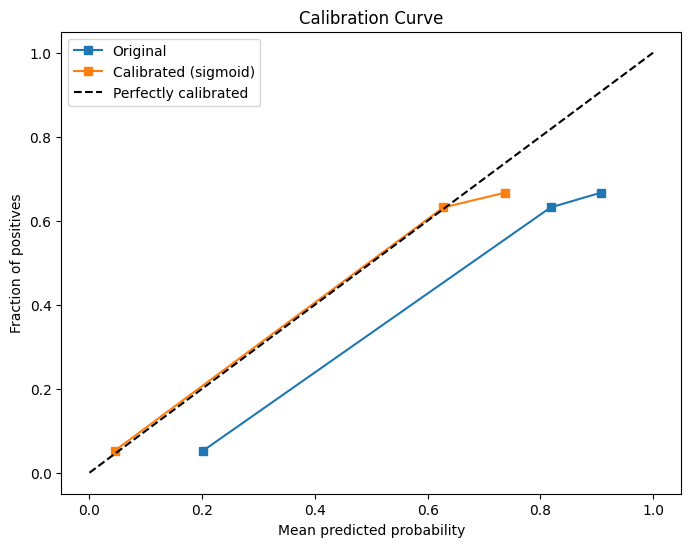


Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.84      0.89       151
           1       0.64      0.86      0.73        49

    accuracy                           0.84       200
   macro avg       0.79      0.85      0.81       200
weighted avg       0.87      0.84      0.85       200

ROC-AUC: 0.8398
PR-AUC: 0.5916


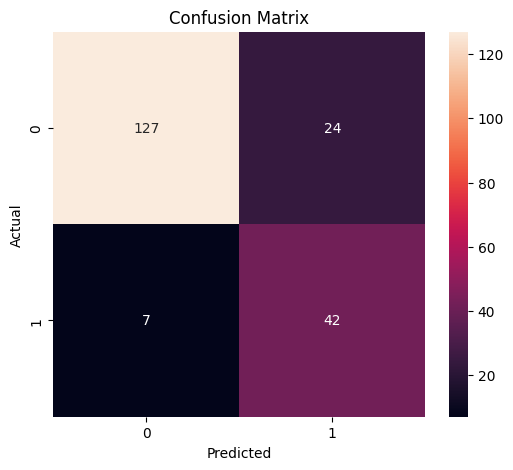

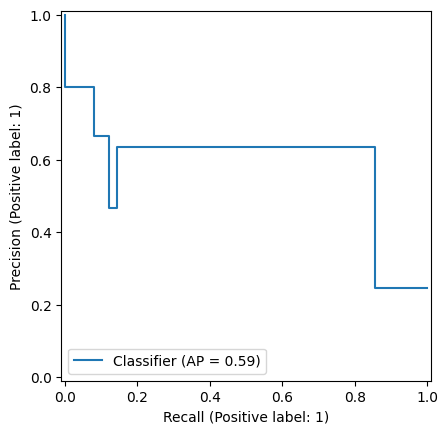

In [324]:
calibrated_xgb = calibrate_model(best_xgb, X_train_xgb, y_train, X_test_xgb, y_test, method='sigmoid')

y_pred_cal = calibrated_xgb.predict(X_test_xgb)
y_score_cal = calibrated_xgb.predict_proba(X_test_xgb)[:, 1]

evaluate_model(calibrated_xgb, X_test_xgb, y_test)
plot_results(y_test, y_pred_cal, y_score_cal)

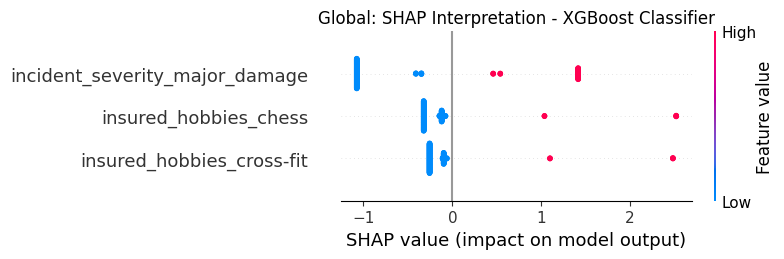

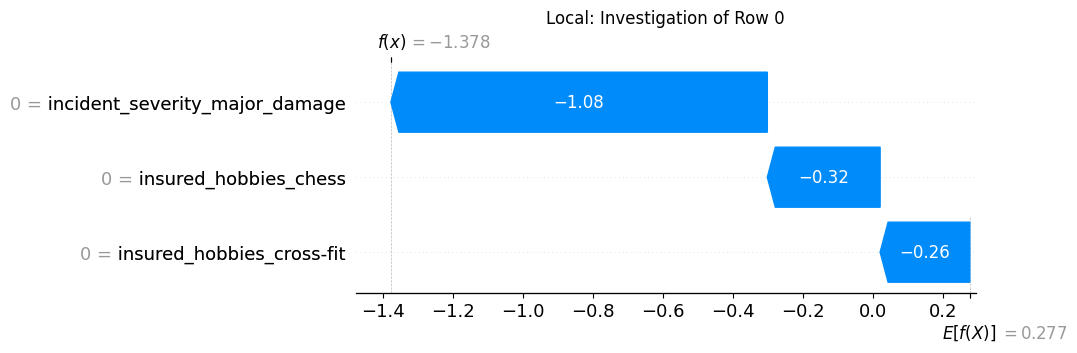

In [325]:
plot_shap_interpretation(best_xgb, X_test_xgb, feature_names=selected_features, title="SHAP Interpretation - XGBoost Classifier")

## 11. Comparison between models

In [326]:
def compare_models(models, y_test):
    results = []
    for name, model, X in models:
        probs = model.predict_proba(X)[:, 1]
        results.append({
            'Model': name,
            'ROC-AUC': roc_auc_score(y_test, probs),
            'PR-AUC': average_precision_score(y_test, probs),
            'Brier Score': brier_score_loss(y_test, probs)
        })
    return pd.DataFrame(results)

# Usage:
model_list = [
    ('Logistic Regression', calibrated_lr, X_test_lr), 
    ('XGBoost', calibrated_xgb, X_test_xgb)
]
comparison_df = compare_models(model_list, y_test)
display(comparison_df)

,Model,ROC-AUC,PR-AUC,Brier Score
0,Logistic Regression,0.869712,0.572343,0.121070
1,XGBoost,0.839776,0.591586,0.111094


In [327]:
best_model_name = comparison_df.sort_values(by='PR-AUC', ascending=False).iloc[0]['Model']
print("Best model based on PR-AUC: ", best_model_name)

Best model based on PR-AUC:  XGBoost


## 12. Exporting model via Joblib

In [328]:
import joblib

model_filename = 'fraud_detection_model_v1.pkl'

joblib.dump(calibrated_xgb, model_filename)

print(f"Model successfully saved to {model_filename}")

Model successfully saved to fraud_detection_model_v1.pkl
